# Числове дослідження МНС і ПАРТАН-МНС

## 1. Постановка задачі

Дослідити збіжність методу найшвидшого спуску та ПАРТАН-методу найшвидшого спуску при мінімізації степеневої функції залежно від параметрів методу, а також використати метод штрафних функцій для задачі умовної оптимізації при розташуванні локального мінімуму поза випуклою допустимою областю.

Дослідження включає такі пункти постановки задачі:

1. Величина кроку `h` при обчисленні похідних: розд. 4.1
2. Схема обчислення похідних (пряма / зворотна / центральна): розд. 4.2
3. Вид методу одновимірного пошуку: розд. 4.3
4. Точність методу одновимірного пошуку `line_search_eps`: розд. 4.4
5. Значення параметра алгоритму Свена `sven_alpha`: розд. 4.5
6. Вид критерію закінчення (градієнтний / комбінований): розд. 4.6
7. Порівняння МНС і ПАРТАН-МНС: розд. 4.7–4.9
8. Метод штрафних функцій для умовної оптимізації: розд. 5

**Цільова функція:** `f(x) = (10·(x₁ − x₂)² + (x₁ − 1)²)⁴`

**Обмеження (умовна задача):** `x₁² + x₂² ≤ 1`

Безумовний мінімум `x* = (1, 1)` знаходиться поза допустимою областю, тому метод штрафних функцій наближає результат до межі кола.

In [33]:
import turtle
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "optimization").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import optimization.experiments as experiments
experiments = importlib.reload(experiments)

BASE_PARAMS = experiments.BASE_PARAMS
EXPERIMENTS = experiments.EXPERIMENTS
METHODS = experiments.METHODS
DISPLAY_COLUMN_LABELS = experiments.DISPLAY_COLUMN_LABELS
compare_methods = experiments.compare_methods
compare_line_search_precision = experiments.compare_line_search_precision
compare_penalty_methods = experiments.compare_penalty_methods
compare_penalty_start_points = experiments.compare_penalty_start_points
distance_to_circle_boundary = experiments.distance_to_circle_boundary
format_point = experiments.format_point
old_sympy_check = experiments.old_sympy_check
penalty_experiment_summary = experiments.penalty_experiment_summary
sympy_penalty_s4_check = experiments.sympy_penalty_s4_check
sweep = experiments.sweep

from optimization.functions import F_MIN, FUNCTION_FORMULA, X_MIN, X_START, power_function
from optimization.partan_steepest_descent import partan_steepest_descent
from optimization.penalty import circle_constraint, make_external_penalty_function
import optimization.plots as plots
plots = importlib.reload(plots)
plot_circle_constraint = plots.plot_circle_constraint
plot_combined_trajectories = plots.plot_combined_trajectories if hasattr(plots, "plot_combined_trajectories") else None
plot_convergence_by_iteration = plots.plot_convergence_by_iteration
plot_cumulative_calls_by_iteration = plots.plot_cumulative_calls_by_iteration
plot_final_comparison = plots.plot_final_comparison
plot_gradient_norm_by_iteration = plots.plot_gradient_norm_by_iteration
plot_metric_by_parameter = plots.plot_metric_by_parameter
plot_penalty_trajectory = plots.plot_penalty_trajectory
plot_trajectory = plots.plot_trajectory
plots.use_light_plot_theme()
from optimization.steepest_descent import steepest_descent

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (8, 4)

base_params = BASE_PARAMS.copy()
base_params

{'max_iter': 1000,
 'eps': 0.001,
 'derivative_h': 0.001,
 'gradient_scheme': 'central',
 'line_search_method': 'dsk_powell',
 'line_search_eps': 1e-08,
 'sven_alpha': 0.01,
 'stop_criterion': 'combined'}

In [34]:
COLUMN_LABELS: dict[str, str] = {
    "task": "задача",
    "method": "метод",
    "parameter_value": "значення параметра",
    "x_final": "кінцева точка",
    "f_final": "кінцеве значення функції",
    "grad_norm_final": "норма градієнта",
    "iterations": "кількість ітерацій",
    "func_calls": "кількість викликів функції",
    "status": "статус",
}
for label_key, label_value in DISPLAY_COLUMN_LABELS.items():
    COLUMN_LABELS[str(label_key)] = str(label_value)

PARAMETER_LABELS = {
    "derivative_h": "крок h",
    "gradient_scheme": "схема чисельного диференціювання",
    "line_search_method": "метод одновимірного пошуку",
    "line_search_eps": "точність одновимірного пошуку",
    "sven_alpha": "параметр α методу Свена",
    "stop_criterion": "критерій зупинки",
}

CONCLUSIONS = {
    "derivative_h": "Малий крок дає точніше чисельне наближення похідної, але може збільшувати кількість обчислень або викликати числову нестабільність. Надто великий крок може давати грубе наближення градієнта.",
    "gradient_scheme": "Центральна схема зазвичай дає точніше наближення похідної, але може потребувати більше викликів функції, бо для кожної координати функція обчислюється з двох боків.",
    "line_search_method": "Метод одновимірного пошуку впливає не тільки на точність вибору кроку λ, але й на загальну кількість викликів цільової функції.",
    "line_search_eps": "Занадто груба точність одновимірного пошуку може погіршити кінцеву точність, а занадто мала точність може збільшити кількість викликів функції без суттєвого покращення результату.",
    "sven_alpha": "Параметр Свена впливає на початкову локалізацію інтервалу для одновимірного пошуку. Невдале значення може збільшити кількість обчислень функції.",
    "stop_criterion": "Комбінований критерій враховує не тільки норму градієнта, але й зміну точки або значення функції, тому може бути практичнішим для чисельних методів.",
}

BEST_EXPERIMENT_PARAMS = {
    # Fill manually after experiments, example:
    "derivative_h": 1e-3,
    "gradient_scheme": "central",
    "line_search_method": "dsk_powell",
    "line_search_eps": 1e-8,
    "sven_alpha": 0.01,
    "stop_criterion": "combined",
}


def build_tuned_params(params):
    tuned_params = dict(params)
    for param_name, param_value in BEST_EXPERIMENT_PARAMS.items():
        if param_name in tuned_params:
            tuned_params[param_name] = param_value
    return tuned_params


def show_best_params_summary(title="Manual best params"):
    if not BEST_EXPERIMENT_PARAMS:
        display(Markdown("**BEST_EXPERIMENT_PARAMS is empty. Using base_params.**"))
        return

    summary_rows = []
    for key, value in BEST_EXPERIMENT_PARAMS.items():
        summary_rows.append({
            INFO_COL: PARAMETER_LABELS.get(str(key), str(key)),
            VALUE_COL: value,
        })
    display(Markdown(f"#### {title}"))
    display(pd.DataFrame(summary_rows))


def format_vector(vector_value):
    vector_arr = np.asarray(vector_value, dtype=float).reshape(-1)
    return "[" + ", ".join(f"{item:.8f}" for item in vector_arr) + "]"


def parse_point(value):
    if isinstance(value, str):
        return np.fromstring(value.strip("[]"), sep=",")
    return np.asarray(value, dtype=float).reshape(-1)


def format_display_value(value):
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.3e}"
    return value


def show_table(data_frame):
    formatted_table = data_frame.copy()
    for column_name in formatted_table.columns:
        formatted_table[column_name] = formatted_table[column_name].map(format_display_value)
    display(formatted_table.rename(columns=COLUMN_LABELS))


INFO_COL = "\u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440"
VALUE_COL = "\u0437\u043d\u0430\u0447\u0435\u043d\u043d\u044f"


def format_values_summary(values, max_items=8):
    value_list = list(values)
    shown_values = value_list[:max_items]
    summary = ", ".join(str(value) for value in shown_values)
    if len(value_list) > max_items:
        summary += f", ... ({len(value_list)} total)"
    return summary


def show_test_initial_data(
    test_name,
    varied_parameter=None,
    varied_values=None,
    methods=None,
    params=None,
    start_point=None,
    extra_rows=None,
):
    params = dict(base_params if params is None else params)
    start = np.asarray(X_START if start_point is None else start_point, dtype=float).reshape(-1)
    rows = [
        {INFO_COL: "\u0442\u0435\u0441\u0442", VALUE_COL: test_name},
        {INFO_COL: "\u0444\u0443\u043d\u043a\u0446\u0456\u044f", VALUE_COL: FUNCTION_FORMULA},
        {INFO_COL: "\u0441\u0442\u0430\u0440\u0442\u043e\u0432\u0430 \u0442\u043e\u0447\u043a\u0430", VALUE_COL: format_vector(start)},
        {INFO_COL: "f(x_start)", VALUE_COL: f"{power_function(start):.2e}"},
    ]

    if methods is not None:
        rows.append({INFO_COL: "\u043c\u0435\u0442\u043e\u0434\u0438", VALUE_COL: ", ".join(str(method) for method in methods)})
    if varied_parameter is not None:
        rows.append({INFO_COL: "\u0437\u043c\u0456\u043d\u043d\u0438\u0439 \u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440", VALUE_COL: str(varied_parameter)})
    if varied_values is not None:
        rows.append({INFO_COL: "\u0437\u043d\u0430\u0447\u0435\u043d\u043d\u044f \u0437\u043c\u0456\u043d\u043d\u043e\u0433\u043e \u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440\u0430", VALUE_COL: format_values_summary(varied_values)})
    if extra_rows is not None:
        for row in extra_rows:
            if INFO_COL in row and VALUE_COL in row:
                rows.append(row)
            else:
                rows.append({INFO_COL: row.get("parameter", ""), VALUE_COL: row.get("value", "")})

    for param_name, param_value in params.items():
        rows.append({INFO_COL: f"base_params[{param_name}]", VALUE_COL: str(param_value)})

    display(Markdown("#### \u041f\u043e\u0447\u0430\u0442\u043a\u043e\u0432\u0456 \u0434\u0430\u043d\u0456 \u0442\u0435\u0441\u0442\u0443"))
    display(pd.DataFrame(rows))


def show_plot_heading(title):
    if title:
        display(Markdown(f"#### {title}"))


def _remove_plot_title(args, kwargs, title_index):
    args = list(args)
    kwargs = dict(kwargs)
    if len(args) > title_index:
        title = args[title_index]
        args[title_index] = ""
    else:
        title = kwargs.get("title", "")
        kwargs["title"] = ""
    return title, tuple(args), kwargs


_plot_metric_by_parameter = plots.plot_metric_by_parameter
def plot_metric_by_parameter(*args, **kwargs):
    title, args, kwargs = _remove_plot_title(args, kwargs, 3)
    show_plot_heading(title)
    return _plot_metric_by_parameter(*args, **kwargs)


_plot_final_comparison = plots.plot_final_comparison
def plot_final_comparison(*args, **kwargs):
    title, args, kwargs = _remove_plot_title(args, kwargs, 2)
    show_plot_heading(title)
    return _plot_final_comparison(*args, **kwargs)


_plot_trajectory = plots.plot_trajectory
def plot_trajectory(*args, **kwargs):
    title, args, kwargs = _remove_plot_title(args, kwargs, 2)
    title_text = str(title)
    if "ПАРТАН-МНС" in title_text or "PARTAN" in title_text:
        kwargs.setdefault("trajectory_color", "navy")
    elif "МНС" in title_text or "MNS" in title_text:
        kwargs.setdefault("trajectory_color", "orange")
    show_plot_heading(title)
    return _plot_trajectory(*args, **kwargs)


_plot_convergence_by_iteration = plots.plot_convergence_by_iteration
def plot_convergence_by_iteration(*args, **kwargs):
    title, args, kwargs = _remove_plot_title(args, kwargs, 1)
    show_plot_heading(title)
    return _plot_convergence_by_iteration(*args, **kwargs)


_plot_gradient_norm_by_iteration = plots.plot_gradient_norm_by_iteration
def plot_gradient_norm_by_iteration(*args, **kwargs):
    title, args, kwargs = _remove_plot_title(args, kwargs, 1)
    show_plot_heading(title)
    return _plot_gradient_norm_by_iteration(*args, **kwargs)


_plot_cumulative_calls_by_iteration = plots.plot_cumulative_calls_by_iteration
def plot_cumulative_calls_by_iteration(*args, **kwargs):
    title, args, kwargs = _remove_plot_title(args, kwargs, 1)
    show_plot_heading(title)
    return _plot_cumulative_calls_by_iteration(*args, **kwargs)


def sweep_table(parameter_name):
    sweep_frames = []
    for method_name, sweep_method_callable in METHODS.items():
        sweep_frame = sweep(sweep_method_callable, parameter_name, EXPERIMENTS[parameter_name], base_params=base_params)
        sweep_frame.insert(0, "method", method_name)
        sweep_frames.append(sweep_frame)
    return pd.concat(sweep_frames, ignore_index=True)


def show_sweep(parameter_name, heading):
    display(Markdown(f"### {heading}"))
    show_test_initial_data(
        heading,
        varied_parameter=PARAMETER_LABELS.get(parameter_name, parameter_name),
        varied_values=EXPERIMENTS[parameter_name],
        methods=list(METHODS),
    )
    sweep_result_table = sweep_table(parameter_name)
    show_table(sweep_result_table)

    log_x = parameter_name in {"derivative_h", "line_search_eps", "sven_alpha"}
    xlabel = PARAMETER_LABELS.get(parameter_name, parameter_name)
    sweep_metrics = [
        ("iterations", "кількість ітерацій", False),
        ("func_calls", "кількість викликів функції", False),
        ("x_error", "відстань до точного мінімуму", True),
    ]
    for metric_name, y_axis_label, use_log_y in sweep_metrics:
        _, sweep_ax = plt.subplots(figsize=(8, 4.5))
        plot_metric_by_parameter(
            sweep_result_table,
            parameter_col="parameter_value",
            metric_col=metric_name,
            title=f"{xlabel} -> {y_axis_label}",
            xlabel=xlabel,
            ylabel=y_axis_label,
            log_x=log_x,
            log_y=use_log_y,
            ax=sweep_ax,
        )
        plt.tight_layout()
        plt.show()
    display(Markdown(f"**Висновок.** {CONCLUSIONS[parameter_name]}"))
    return sweep_result_table

def contour_grid(trajectory_points):
    grid_points = np.asarray(trajectory_points, dtype=float)
    x_min = float(grid_points[:, 0].min())
    x_max = float(grid_points[:, 0].max())
    y_min = float(grid_points[:, 1].min())
    y_max = float(grid_points[:, 1].max())
    span = max(x_max - x_min, y_max - y_min, 1e-12)
    grid_pad = 0.12 * span
    grid_x_values = np.linspace(x_min - grid_pad, x_max + grid_pad, 260)
    grid_y_values = np.linspace(y_min - grid_pad, y_max + grid_pad, 260)
    grid_x, grid_y = np.meshgrid(grid_x_values, grid_y_values)
    grid_z = np.vectorize(lambda a, b: power_function(np.array([a, b], dtype=float)))(grid_x, grid_y)
    return grid_x, grid_y, grid_z




def padded_limits(values, log_scale=False, pad_ratio=0.12):
    finite_values = np.asarray(values, dtype=float).reshape(-1)
    finite_values = finite_values[np.isfinite(finite_values)]
    if log_scale:
        finite_values = finite_values[finite_values > 0]
    if finite_values.size == 0:
        return None

    min_value = float(finite_values.min())
    max_value = float(finite_values.max())
    if log_scale:
        if np.isclose(min_value, max_value):
            return min_value / 10, max_value * 10
        pad = (max_value / min_value) ** pad_ratio
        return min_value / pad, max_value * pad

    if np.isclose(min_value, max_value):
        pad = max(abs(min_value) * 0.1, 1.0)
    else:
        pad = (max_value - min_value) * pad_ratio
    return min_value - pad, max_value + pad


def apply_padded_axis_limits(ax, x_values=None, y_values=None, x_log=False, y_log=False, y_include=None):
    if x_values is not None:
        x_limits = padded_limits(x_values, log_scale=x_log)
        if x_limits is not None:
            ax.set_xlim(*x_limits)
    if y_values is not None:
        y_array = np.asarray(y_values, dtype=float).reshape(-1)
        if y_include is not None:
            y_array = np.concatenate([y_array, np.asarray(y_include, dtype=float).reshape(-1)])
        y_limits = padded_limits(y_array, log_scale=y_log)
        if y_limits is not None:
            ax.set_ylim(*y_limits)


def apply_equal_data_limits(ax, points, pad_ratio=0.12, include_unit_circle=False):
    plot_points = np.asarray(points, dtype=float).reshape(-1, 2)
    plot_points = plot_points[np.all(np.isfinite(plot_points), axis=1)]
    if include_unit_circle:
        plot_points = np.vstack([plot_points, np.array([[-1.0, -1.0], [1.0, 1.0]], dtype=float)])
    if plot_points.size == 0:
        return

    x_min, y_min = plot_points.min(axis=0)
    x_max, y_max = plot_points.max(axis=0)
    span = max(float(x_max - x_min), float(y_max - y_min), 1e-12)
    pad = span * pad_ratio
    x_center = float((x_min + x_max) / 2)
    y_center = float((y_min + y_max) / 2)
    half = span / 2 + pad
    ax.set_xlim(x_center - half, x_center + half)
    ax.set_ylim(y_center - half, y_center + half)
    ax.set_aspect("equal", adjustable="box")

def plot_combined_trajectories(results_by_method, plot_title):
    combined_points = np.vstack([method_result["points"] for method_result in results_by_method.values()])
    contour_x, contour_y, contour_z = contour_grid(combined_points)
    _, combined_ax = plt.subplots(figsize=(8, 6))
    combined_ax.contour(contour_x, contour_y, contour_z, levels=28, cmap="viridis", alpha=0.6)
    trajectory_method_colors = {"МНС": "orange", "ПАРТАН-МНС": "navy"}
    fallback_colors = ["tab:green", "tab:red", "tab:purple", "tab:brown"]
    for color_index, (method_name, method_result) in enumerate(results_by_method.items()):
        method_points = np.asarray(method_result["points"], dtype=float)
        method_color = trajectory_method_colors.get(method_name, fallback_colors[color_index % len(fallback_colors)])
        combined_ax.plot(
            method_points[:, 0],
            method_points[:, 1],
            "o-",
            linewidth=1.8,
            markersize=4.5,
            color=method_color,
            label=method_name,
        )
        combined_ax.scatter(
            method_points[-1, 0],
            method_points[-1, 1],
            s=85,
            color=method_color,
            edgecolor="black",
            linewidth=1.0,
        )
    combined_ax.scatter([X_START[0]], [X_START[1]], marker="s", s=60, color="tab:purple", label="стартова точка")
    combined_ax.scatter([X_MIN[0]], [X_MIN[1]], marker="*", s=120, color="tab:green", label="очікуваний мінімум")
    show_plot_heading(plot_title)
    combined_ax.set_xlabel("x1")
    combined_ax.set_ylabel("x2")
    combined_ax.grid(True, linestyle="--", alpha=0.85)
    combined_ax.set_aspect("equal", adjustable="box")
    combined_ax.legend()
    plt.tight_layout()
    plt.show()


## 2. Початкова функція та стартові дані

,назва,значення
0,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
1,x_start,"[-1.20000000, 0.00000000]"
2,x_min,"[1.00000000, 1.00000000]"
3,f_min,0.0
4,f(x_start),137031.455542


#### Лінії рівня цільової функції

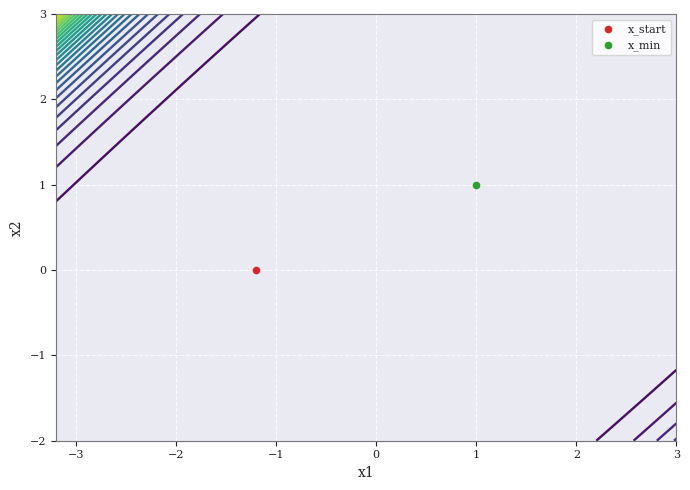

In [35]:
initial_table = pd.DataFrame([
    {"назва": "функція", "значення": FUNCTION_FORMULA},
    {"назва": "x_start", "значення": format_vector(X_START)},
    {"назва": "x_min", "значення": format_vector(X_MIN)},
    {"назва": "f_min", "значення": F_MIN},
    {"назва": "f(x_start)", "значення": power_function(X_START)},
])
display(initial_table)

ref_points = np.array([X_START, X_MIN], dtype=float)
pad = 2
x1 = np.linspace(float(ref_points[:, 0].min()) - pad, float(ref_points[:, 0].max()) + pad, 260)
x2 = np.linspace(float(ref_points[:, 1].min()) - pad, float(ref_points[:, 1].max()) + pad, 260)
X, Y = np.meshgrid(x1, x2)
Z = np.vectorize(lambda a, b: power_function(np.array([a, b], dtype=float)))(X, Y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.contour(X, Y, Z, levels=30, cmap="viridis")
ax.scatter([X_START[0]], [X_START[1]], color="tab:red", label="x_start")
ax.scatter([X_MIN[0]], [X_MIN[1]], color="tab:green", label="x_min")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
show_plot_heading("Лінії рівня цільової функції")
ax.grid(True, linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Пояснення чисельних методів

У роботі похідні обчислюються чисельно. Порівнюються пряма, зворотна та центральна схеми. Центральна схема зазвичай точніша, але потребує більше викликів функції.

На кожній ітерації напрямок спуску уточнюється одновимірним пошуком. Спочатку метод Свена знаходить інтервал, після чого мінімум шукається методом золотого перетину або методом ДСК-Пауелла. Точність `line_search_eps` важлива, бо для степеневої функції оптимальний крок може бути дуже малим.

Для штрафної функції використовується комбінований критерій зупинки, бо поблизу межі області градієнт штрафу може поводитися жорстко, хоча точка вже майже не змінюється.

## 4. Безумовна оптимізація

### 4.1. Вплив величини кроку при обчисленні похідних

#### Початкові дані тесту

,параметр,значення
0,тест,Вплив величини кроку при обчисленні похідних
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,крок h
6,значення змінного параметра,"1, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-..."
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,1.000e+00,"[1.00108831, 0.99922653]",1.651e-18,2.573e+02,1.335e-03,1000,13358,ліміт ітерацій
1,МНС,1.000e-01,"[1.00070379, 0.99950034]",5.033e-20,1.665e-04,8.631e-04,1000,15043,ліміт ітерацій
2,МНС,1.000e-02,"[0.99743058, 0.99688477]",8.427e-21,5.539e-11,4.038e-03,8,171,збіжність
3,МНС,1.000e-03,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,5.190e-03,8,161,збіжність
4,МНС,1.000e-04,"[0.99628887, 0.99606493]",4.151e-20,6.376e-17,5.409e-03,8,161,збіжність
5,МНС,1.000e-05,"[0.99628672, 0.99606293]",4.169e-20,6.258e-17,5.412e-03,8,161,збіжність
6,МНС,1.000e-06,"[0.99628669, 0.99606291]",4.169e-20,6.257e-17,5.412e-03,8,161,збіжність
7,МНС,1.000e-07,"[0.99628669, 0.99606290]",4.169e-20,6.257e-17,5.412e-03,8,161,збіжність
8,МНС,1.000e-08,"[0.99628664, 0.99606285]",4.170e-20,6.257e-17,5.412e-03,8,161,збіжність
9,МНС,1.000e-09,"[0.99628663, 0.99606284]",4.170e-20,6.258e-17,5.412e-03,8,161,збіжність


#### Методи для графіка: `МНС`, `ПАРТАН-МНС`

#### Вплив h на кількість викликів функції

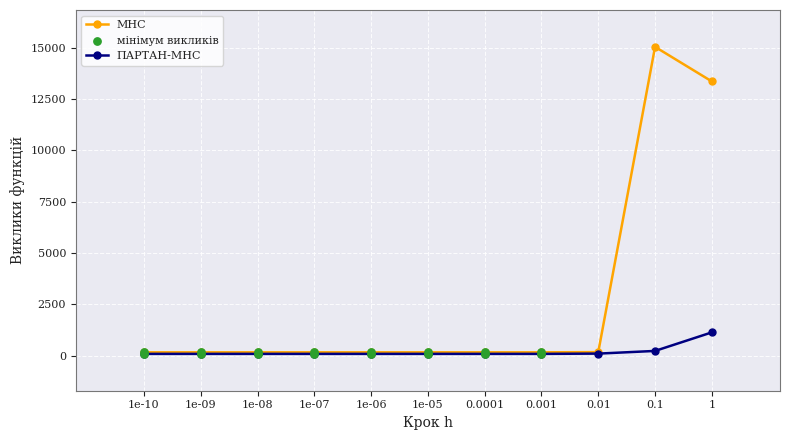

#### Вплив h на кількість ітерацій

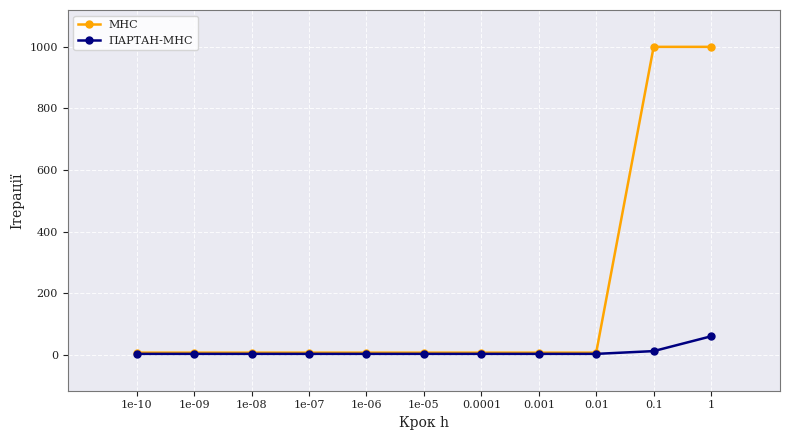

#### Вплив h на норму градієнта

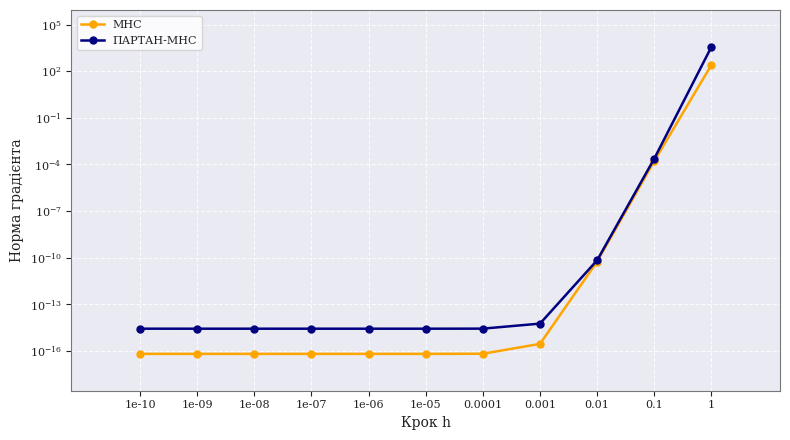

In [36]:
display(Markdown("### 4.1. Вплив величини кроку при обчисленні похідних"))
show_test_initial_data(
    "Вплив величини кроку при обчисленні похідних",
    varied_parameter=PARAMETER_LABELS["derivative_h"],
    varied_values=EXPERIMENTS["derivative_h"],
    methods=list(METHODS),
)
h_table = sweep_table("derivative_h")
show_table(h_table)

main_method_names = ["МНС", "ПАРТАН-МНС"]
derivative_h_calls = h_table[h_table["method"].isin(main_method_names)].copy()
derivative_h_calls["parameter_value"] = derivative_h_calls["parameter_value"].astype(float)
derivative_h_calls = derivative_h_calls.sort_values(["method", "parameter_value"])

display(Markdown("#### Методи для графіка: `МНС`, `ПАРТАН-МНС`"))

show_plot_heading("Вплив h на кількість викликів функції")
fig, ax = plt.subplots(figsize=(8, 4.5))
method_colors = {"МНС": "orange", "ПАРТАН-МНС": "navy"}
all_h_values = []
all_call_values = []
best_label_added = False
for method_name, method_group in derivative_h_calls.groupby("method", sort=False):
    h_values = method_group["parameter_value"].to_numpy(dtype=float)
    call_values = method_group["func_calls"].to_numpy(dtype=float)
    all_h_values.extend(h_values)
    all_call_values.extend(call_values)
    min_call_value = float(np.nanmin(call_values))
    ax.plot(
        h_values,
        call_values,
        "o-",
        color=method_colors.get(method_name),
        linewidth=1.8,
        markersize=5,
        label=method_name,
    )
    best_mask = np.isclose(call_values, min_call_value)
    best_label = "мінімум викликів" if not best_label_added else None
    ax.scatter(h_values[best_mask], call_values[best_mask], color="tab:green", s=28, zorder=4, label=best_label)
    best_label_added = True

all_h_values = np.asarray(all_h_values, dtype=float)
all_call_values = np.asarray(all_call_values, dtype=float)
ax.set_xscale("log")
ax.set_xticks(np.sort(np.unique(all_h_values)))
ax.set_xticklabels([f"{value:g}" for value in np.sort(np.unique(all_h_values))], rotation=0)
ax.set_xlabel("Крок h")
ax.set_ylabel("Виклики функцій")
apply_padded_axis_limits(ax, all_h_values, all_call_values, x_log=True)
ax.grid(True, which="both", linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()

show_plot_heading("Вплив h на кількість ітерацій")
fig, ax = plt.subplots(figsize=(8, 4.5))
all_h_values = []
all_iter_values = []
for method_name, method_group in derivative_h_calls.groupby("method", sort=False):
    h_values = method_group["parameter_value"].to_numpy(dtype=float)
    iter_values = method_group["iterations"].to_numpy(dtype=float)
    all_h_values.extend(h_values)
    all_iter_values.extend(iter_values)
    ax.plot(
        h_values,
        iter_values,
        "o-",
        color=method_colors.get(method_name),
        linewidth=1.8,
        markersize=5,
        label=method_name,
    )

all_h_values = np.asarray(all_h_values, dtype=float)
all_iter_values = np.asarray(all_iter_values, dtype=float)
ax.set_xscale("log")
ax.set_xticks(np.sort(np.unique(all_h_values)))
ax.set_xticklabels([f"{value:g}" for value in np.sort(np.unique(all_h_values))], rotation=0)
ax.set_xlabel("Крок h")
ax.set_ylabel("Ітерації")
apply_padded_axis_limits(ax, all_h_values, all_iter_values, x_log=True)
ax.grid(True, which="both", linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()

show_plot_heading("Вплив h на норму градієнта")
fig, ax = plt.subplots(figsize=(8, 4.5))
all_h_values = []
all_grad_values = []
for method_name, method_group in derivative_h_calls.groupby("method", sort=False):
    h_values = method_group["parameter_value"].to_numpy(dtype=float)
    grad_values = method_group["grad_norm_final"].to_numpy(dtype=float)
    all_h_values.extend(h_values)
    all_grad_values.extend(grad_values)
    ax.plot(
        h_values,
        grad_values,
        "o-",
        color=method_colors.get(method_name),
        linewidth=1.8,
        markersize=5,
        label=method_name,
    )

all_h_values = np.asarray(all_h_values, dtype=float)
all_grad_values = np.asarray(all_grad_values, dtype=float)
ax.set_xscale("log")
if np.all(all_grad_values > 0):
    ax.set_yscale("log")
ax.set_xticks(np.sort(np.unique(all_h_values)))
ax.set_xticklabels([f"{value:g}" for value in np.sort(np.unique(all_h_values))], rotation=0)
ax.set_xlabel("Крок h")
ax.set_ylabel("Норма градієнта")
apply_padded_axis_limits(ax, all_h_values, all_grad_values, x_log=True, y_log=ax.get_yscale() == "log")
ax.grid(True, which="both", linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()


**Оновлення після 4.1:** base_params[derivative_h] = 0.001

### 4.2. Вплив схеми чисельного диференціювання

#### Початкові дані тесту

,параметр,значення
0,тест,Вплив схеми чисельного диференціювання
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,схема чисельного диференціювання
6,значення змінного параметра,"forward, backward, central"
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,forward,"[0.98770982, 0.98615467]",9.429e-16,5.786e-13,1.851e-02,6,130,збіжність
1,МНС,backward,"[0.99329481, 0.99262136]",6.001e-18,2.352e-14,9.970e-03,11,218,збіжність
2,МНС,central,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,5.190e-03,8,161,збіжність
3,ПАРТАН-МНС,forward,"[0.99244865, 0.99229643]",1.075e-17,6.301e-15,1.079e-02,20,342,збіжність
4,ПАРТАН-МНС,backward,"[1.01352518, 1.01465719]",1.468e-15,4.020e-13,1.994e-02,8,152,збіжність
5,ПАРТАН-МНС,central,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,9.044e-03,4,85,збіжність


#### Схема чисельного диференціювання -> кількість викликів функції

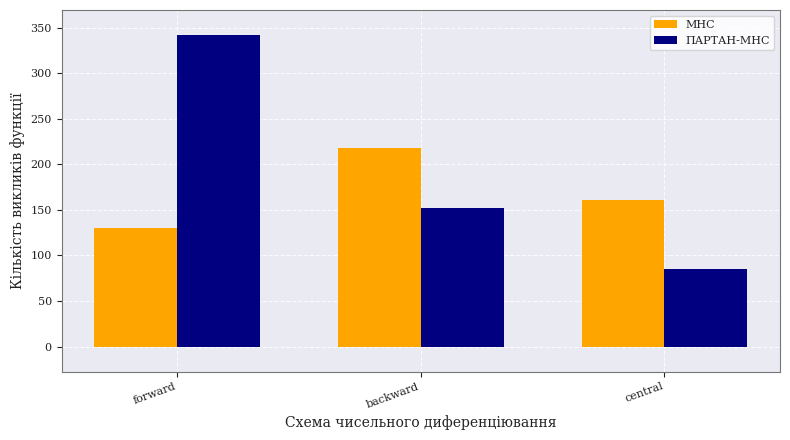

#### Вплив величини кроку та різницевих схем при обчисленні похідних

,схема,h,виклики функції
0,forward,1.000e+00,8548
1,forward,1.000e-01,99
2,forward,1.000e-02,139
3,forward,1.000e-03,342
4,forward,1.000e-04,80
5,forward,1.000e-05,80
6,forward,1.000e-06,80
7,forward,1.000e-07,80
8,forward,1.000e-08,80
9,forward,1.000e-09,80


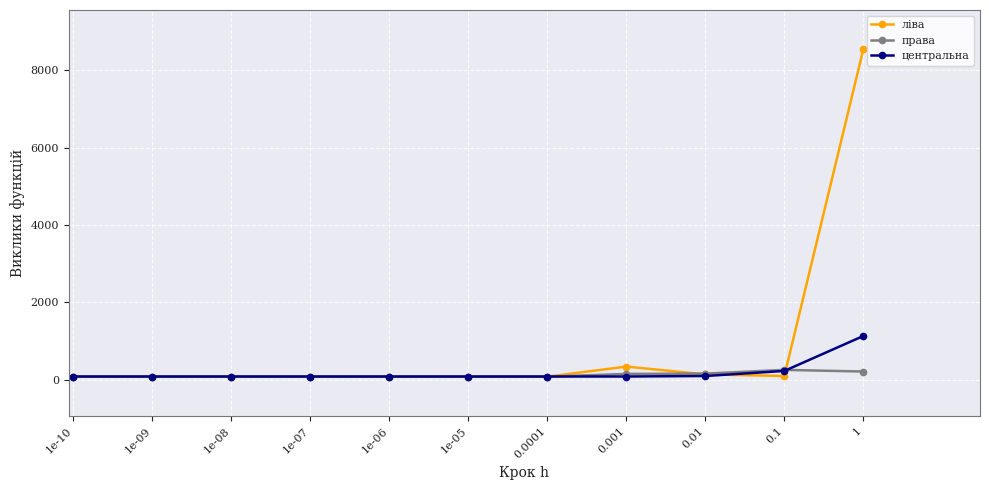

**Висновок.** Схема чисельного диференціювання та крок h впливають на кількість викликів функції, бо змінюють точність наближення градієнта.

In [37]:
base_params["derivative_h"] = 1e-3
display(Markdown("**Оновлення після 4.1:** base_params[derivative_h] = 0.001"))
display(Markdown("### 4.2. \u0412\u043f\u043b\u0438\u0432 \u0441\u0445\u0435\u043c\u0438 \u0447\u0438\u0441\u0435\u043b\u044c\u043d\u043e\u0433\u043e \u0434\u0438\u0444\u0435\u0440\u0435\u043d\u0446\u0456\u044e\u0432\u0430\u043d\u043d\u044f"))
show_test_initial_data(
    "\u0412\u043f\u043b\u0438\u0432 \u0441\u0445\u0435\u043c\u0438 \u0447\u0438\u0441\u0435\u043b\u044c\u043d\u043e\u0433\u043e \u0434\u0438\u0444\u0435\u0440\u0435\u043d\u0446\u0456\u044e\u0432\u0430\u043d\u043d\u044f",
    varied_parameter=PARAMETER_LABELS["gradient_scheme"],
    varied_values=EXPERIMENTS["gradient_scheme"],
    methods=list(METHODS),
)
scheme_table = sweep_table("gradient_scheme")
show_table(scheme_table)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_metric_by_parameter(
    scheme_table,
    parameter_col="parameter_value",
    metric_col="func_calls",
    title="\u0421\u0445\u0435\u043c\u0430 \u0447\u0438\u0441\u0435\u043b\u044c\u043d\u043e\u0433\u043e \u0434\u0438\u0444\u0435\u0440\u0435\u043d\u0446\u0456\u044e\u0432\u0430\u043d\u043d\u044f -> \u043a\u0456\u043b\u044c\u043a\u0456\u0441\u0442\u044c \u0432\u0438\u043a\u043b\u0438\u043a\u0456\u0432 \u0444\u0443\u043d\u043a\u0446\u0456\u0457",
    xlabel="\u0421\u0445\u0435\u043c\u0430 \u0447\u0438\u0441\u0435\u043b\u044c\u043d\u043e\u0433\u043e \u0434\u0438\u0444\u0435\u0440\u0435\u043d\u0446\u0456\u044e\u0432\u0430\u043d\u043d\u044f",
    ylabel="\u041a\u0456\u043b\u044c\u043a\u0456\u0441\u0442\u044c \u0432\u0438\u043a\u043b\u0438\u043a\u0456\u0432 \u0444\u0443\u043d\u043a\u0446\u0456\u0457",
    ax=ax,
)
plt.tight_layout()
plt.show()

display(Markdown("#### \u0412\u043f\u043b\u0438\u0432 \u0432\u0435\u043b\u0438\u0447\u0438\u043d\u0438 \u043a\u0440\u043e\u043a\u0443 \u0442\u0430 \u0440\u0456\u0437\u043d\u0438\u0446\u0435\u0432\u0438\u0445 \u0441\u0445\u0435\u043c \u043f\u0440\u0438 \u043e\u0431\u0447\u0438\u0441\u043b\u0435\u043d\u043d\u0456 \u043f\u043e\u0445\u0456\u0434\u043d\u0438\u0445"))
scheme_h_rows = []
for scheme_name in EXPERIMENTS["gradient_scheme"]:
    for h_value in EXPERIMENTS["derivative_h"]:
        params = base_params.copy()
        params["gradient_scheme"] = scheme_name
        params["derivative_h"] = h_value
        result = partan_steepest_descent(power_function, X_START, **params)
        scheme_h_rows.append({
            "gradient_scheme": scheme_name,
            "derivative_h": h_value,
            "func_calls": result["func_calls"],
        })
scheme_h_table = pd.DataFrame(scheme_h_rows)
show_table(scheme_h_table.rename(columns={
    "gradient_scheme": "\u0441\u0445\u0435\u043c\u0430",
    "derivative_h": "h",
    "func_calls": "\u0432\u0438\u043a\u043b\u0438\u043a\u0438 \u0444\u0443\u043d\u043a\u0446\u0456\u0457",
}))

scheme_labels = {"central": "\u0446\u0435\u043d\u0442\u0440\u0430\u043b\u044c\u043d\u0430", "forward": "\u043b\u0456\u0432\u0430", "backward": "\u043f\u0440\u0430\u0432\u0430"}
scheme_colors = {"central": "navy", "forward": "orange", "backward": "tab:gray"}
fig, ax = plt.subplots(figsize=(10, 5))
all_h_values = []
all_call_values = []
for scheme_name, group in scheme_h_table.groupby("gradient_scheme", sort=False):
    group = group.sort_values("derivative_h")
    h_values = group["derivative_h"].to_numpy(dtype=float)
    call_values = group["func_calls"].to_numpy(dtype=float)
    all_h_values.extend(h_values)
    all_call_values.extend(call_values)
    ax.plot(
        h_values,
        call_values,
        "o-",
        linewidth=1.8,
        markersize=4.5,
        color=scheme_colors.get(scheme_name),
        label=scheme_labels.get(scheme_name, scheme_name),
    )

all_h_values = np.asarray(all_h_values, dtype=float)
all_call_values = np.asarray(all_call_values, dtype=float)
ax.set_xscale("log")
ax.set_xticks(np.sort(np.unique(all_h_values)))
ax.set_xticklabels([f"{value:g}" for value in np.sort(np.unique(all_h_values))], rotation=45, ha="right")
ax.set_xlabel("\u041a\u0440\u043e\u043a h")
ax.set_ylabel("\u0412\u0438\u043a\u043b\u0438\u043a\u0438 \u0444\u0443\u043d\u043a\u0446\u0456\u0439")
apply_padded_axis_limits(ax, all_h_values, all_call_values, x_log=True)
ax.set_xlim(float(np.nanmin(all_h_values)) / 1.15, float(np.nanmax(all_h_values)) * 30.0)
ax.grid(True, which="both", linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown("**\u0412\u0438\u0441\u043d\u043e\u0432\u043e\u043a.** \u0421\u0445\u0435\u043c\u0430 \u0447\u0438\u0441\u0435\u043b\u044c\u043d\u043e\u0433\u043e \u0434\u0438\u0444\u0435\u0440\u0435\u043d\u0446\u0456\u044e\u0432\u0430\u043d\u043d\u044f \u0442\u0430 \u043a\u0440\u043e\u043a h \u0432\u043f\u043b\u0438\u0432\u0430\u044e\u0442\u044c \u043d\u0430 \u043a\u0456\u043b\u044c\u043a\u0456\u0441\u0442\u044c \u0432\u0438\u043a\u043b\u0438\u043a\u0456\u0432 \u0444\u0443\u043d\u043a\u0446\u0456\u0457, \u0431\u043e \u0437\u043c\u0456\u043d\u044e\u044e\u0442\u044c \u0442\u043e\u0447\u043d\u0456\u0441\u0442\u044c \u043d\u0430\u0431\u043b\u0438\u0436\u0435\u043d\u043d\u044f \u0433\u0440\u0430\u0434\u0456\u0454\u043d\u0442\u0430."))


### 4.3. Вплив методу одновимірного пошуку

#### Початкові дані тесту

,параметр,значення
0,тест,4.3. Вплив методу одновимірного пошуку
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,метод одновимірного пошуку
6,значення змінного параметра,"golden, dsk_powell"
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,golden,"[0.99341446, 0.99303302]",4.037e-18,6.438e-15,9.587e-03,10,1052,збіжність
1,МНС,dsk_powell,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,5.190e-03,8,161,збіжність
2,ПАРТАН-МНС,golden,"[0.99940598, 0.99937503]",1.726e-26,4.342e-18,8.622e-04,8,689,збіжність
3,ПАРТАН-МНС,dsk_powell,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,9.044e-03,4,85,збіжність


#### метод одновимірного пошуку -> кількість ітерацій

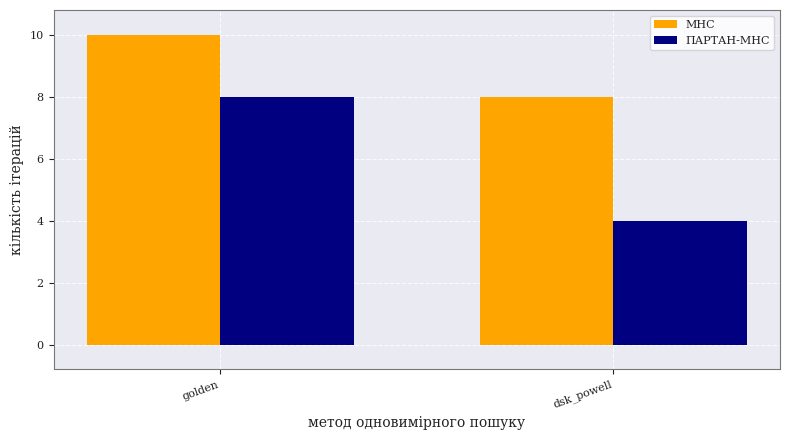

#### метод одновимірного пошуку -> кількість викликів функції

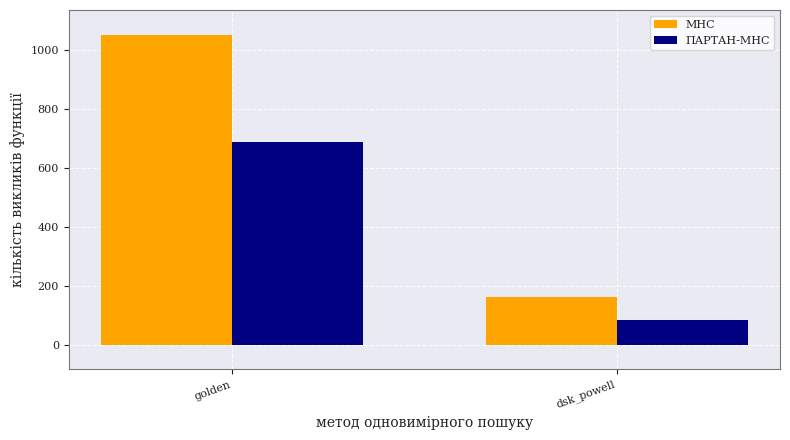

#### метод одновимірного пошуку -> відстань до точного мінімуму

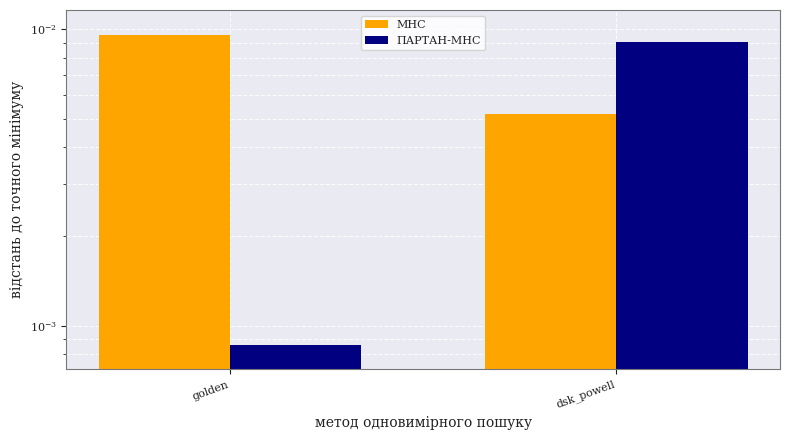

**Висновок.** Метод одновимірного пошуку впливає не тільки на точність вибору кроку λ, але й на загальну кількість викликів цільової функції.

In [38]:
line_search_method_table = show_sweep("line_search_method", "4.3. Вплив методу одновимірного пошуку")

### 4.4. Вплив точності одновимірного пошуку

#### Початкові дані тесту

,параметр,значення
0,тест,4.4. Вплив точності одновимірного пошуку
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,точність одновимірного пошуку
6,значення змінного параметра,"0.1, 0.01, 0.001, 0.0001, 1e-06, 1e-08, 1e-10,..."
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,1.000e-01,"[0.98655759, 0.98527168]",1.513e-15,9.306e-13,1.994e-02,96,1772,збіжність
1,МНС,1.000e-02,"[0.98573694, 0.98445003]",2.342e-15,1.276e-12,2.110e-02,90,1690,збіжність
2,МНС,1.000e-03,"[0.98522910, 0.98391783]",3.069e-15,1.580e-12,2.184e-02,88,1692,збіжність
3,МНС,1.000e-04,"[0.98548225, 0.98415496]",2.720e-15,1.463e-12,2.149e-02,92,1784,збіжність
4,МНС,1.000e-06,"[0.98655677, 0.98532115]",1.475e-15,8.798e-13,1.990e-02,94,1865,збіжність
5,МНС,1.000e-08,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,5.190e-03,8,161,збіжність
6,МНС,1.000e-10,"[0.99743478, 0.99727871]",2.168e-21,7.685e-17,3.740e-03,8,168,збіжність
7,МНС,1.000e-12,"[0.99743478, 0.99727871]",2.168e-21,7.685e-17,3.740e-03,8,169,збіжність
8,ПАРТАН-МНС,1.000e-01,"[1.00528664, 1.00611398]",1.466e-18,7.152e-15,8.083e-03,50,870,збіжність
9,ПАРТАН-МНС,1.000e-02,"[1.01031363, 1.01106855]",1.577e-16,1.189e-13,1.513e-02,56,1006,збіжність


#### точність одновимірного пошуку -> кількість ітерацій

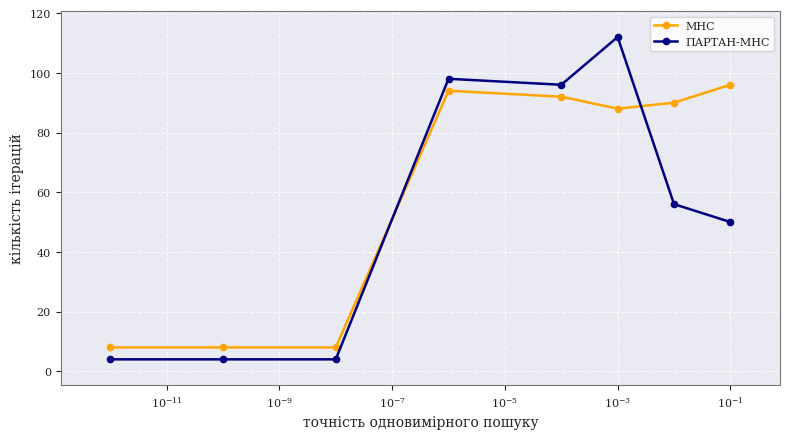

#### точність одновимірного пошуку -> кількість викликів функції

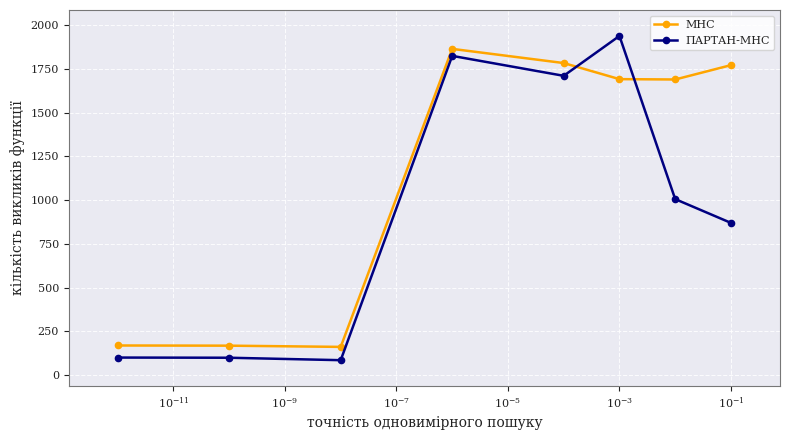

#### точність одновимірного пошуку -> відстань до точного мінімуму

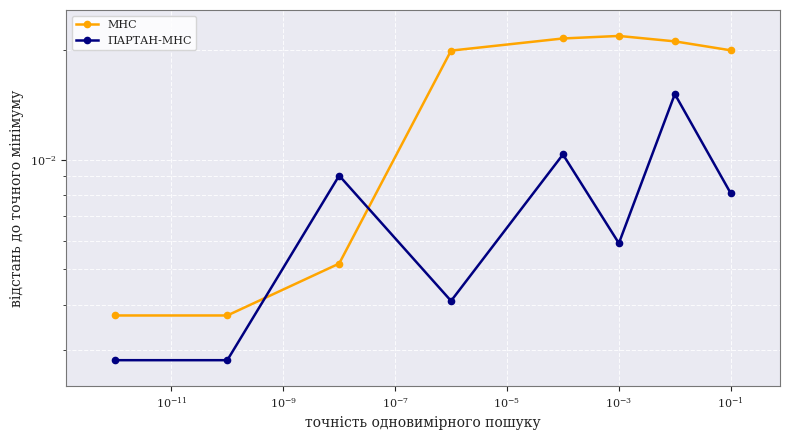

**Висновок.** Занадто груба точність одновимірного пошуку може погіршити кінцеву точність, а занадто мала точність може збільшити кількість викликів функції без суттєвого покращення результату.

In [39]:
line_search_eps_table = show_sweep("line_search_eps", "4.4. Вплив точності одновимірного пошуку")

#### Початкові дані тесту

,параметр,значення
0,тест,Вплив точності одновимірного пошуку
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"ДСК-Пауелла, Golden ratio"
5,змінний параметр,line_search_eps
6,значення змінного параметра,"1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.00..."
7,алгоритм оптимізації,partan_steepest_descent
8,порівнювані методи одновимірного пошуку,"Golden ratio, ДСК-Пауелла"
9,base_params[max_iter],1000


,метод,значення параметра,кількість викликів функції
11,Golden ratio,1.000e-10,172
12,Golden ratio,1.000e-09,511
13,Golden ratio,1.000e-08,689
14,Golden ratio,1.000e-07,456
15,Golden ratio,1.000e-06,86
16,Golden ratio,1.000e-05,411
17,Golden ratio,1.000e-04,365
18,Golden ratio,1.000e-03,320
19,Golden ratio,1.000e-02,812
20,Golden ratio,1.000e-01,641


**Примітка.** `line_search_method` і `line_search_eps` задай вручну в `BEST_EXPERIMENT_PARAMS`.

#### Порівняння Golden ratio та ДСК-Пауелла за різної точності одновимірного пошуку

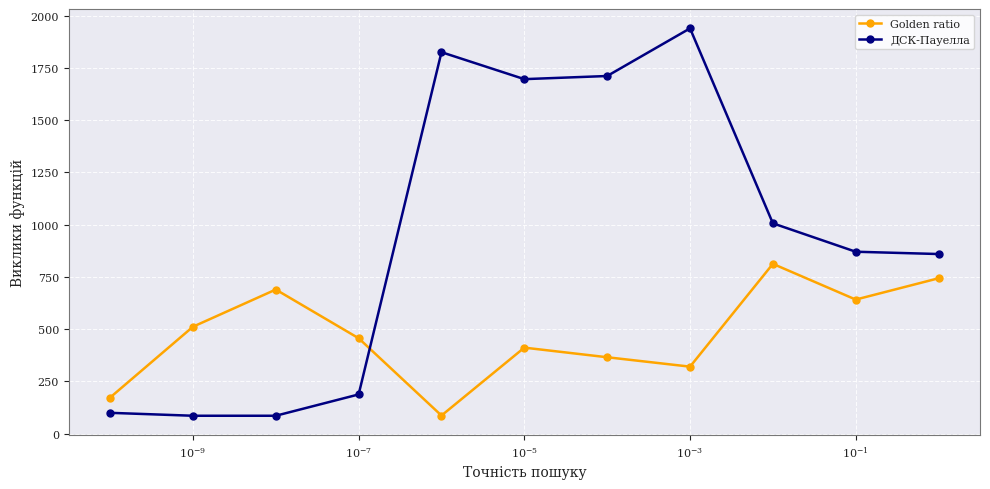

#### Траєкторії пошуку для Golden ratio та ДСК-Пауелла

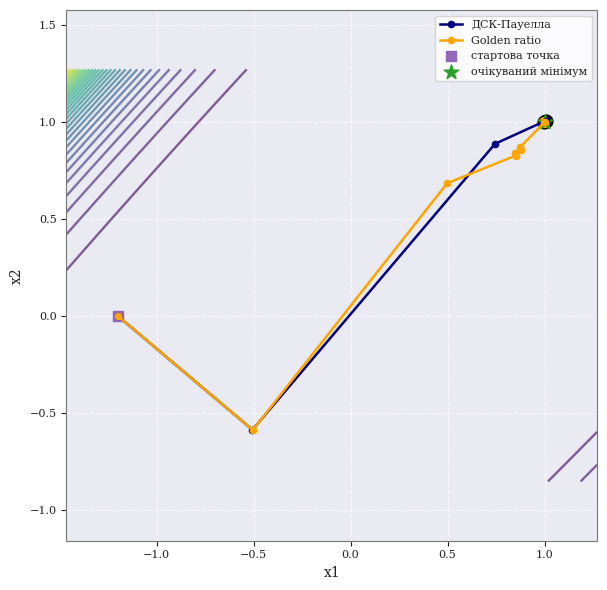

In [40]:
line_search_precision_eps_values = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
line_search_precision_variants = {"ДСК-Пауелла": "dsk_powell", "Golden ratio": "golden"}
show_test_initial_data(
    "Вплив точності одновимірного пошуку",
    varied_parameter="line_search_eps",
    varied_values=line_search_precision_eps_values,
    methods=list(line_search_precision_variants),
    extra_rows=[
        {"parameter": "алгоритм оптимізації", "value": "partan_steepest_descent"},
        {"parameter": "порівнювані методи одновимірного пошуку", "value": "Golden ratio, ДСК-Пауелла"},
    ],
)

results_by_ls = compare_line_search_precision(
    base_params=base_params,
    eps_values=line_search_precision_eps_values,
    line_search_variants=line_search_precision_variants,
)

line_search_precision_rows = []
for display_name, rows in results_by_ls.items():
    for row in rows:
        line_search_precision_rows.append(
            {
                "method": display_name,
                "parameter_value": row["eps"],
                "func_calls": row["func_calls"],
            }
        )
line_search_precision_table = pd.DataFrame(line_search_precision_rows)
line_search_precision_table["parameter_value"] = line_search_precision_table["parameter_value"].astype(float)
line_search_precision_table = line_search_precision_table.sort_values(["method", "parameter_value"])
show_table(line_search_precision_table)

display(Markdown("**Примітка.** `line_search_method` і `line_search_eps` задай вручну в `BEST_EXPERIMENT_PARAMS`."))

ls_colors = {"ДСК-Пауелла": "navy", "Golden ratio": "orange"}
fig, ax = plt.subplots(figsize=(10, 5))
for display_name, method_group in line_search_precision_table.groupby("method", sort=False):
    xs = method_group["parameter_value"].to_numpy(dtype=float)
    ys = method_group["func_calls"].to_numpy(dtype=float)
    ax.plot(xs, ys, "o-", linewidth=1.8, markersize=5, label=display_name, color=ls_colors[display_name])
ax.set_xscale("log")
ax.set_xlabel("Точність пошуку")
ax.set_ylabel("Виклики функцій")
show_plot_heading("Порівняння Golden ratio та ДСК-Пауелла за різної точності одновимірного пошуку")
ax.grid(True, which="both", linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()

line_search_trajectory_results = {}
for display_name, method_key in line_search_precision_variants.items():
    trajectory_params = base_params.copy()
    trajectory_params["line_search_method"] = method_key
    trajectory_params["line_search_eps"] = base_params["line_search_eps"]
    line_search_trajectory_results[display_name] = partan_steepest_descent(power_function, X_START, **trajectory_params)

all_points = np.vstack([result["points"] for result in line_search_trajectory_results.values()])
contour_x, contour_y, contour_z = contour_grid(all_points)
fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(contour_x, contour_y, contour_z, levels=28, cmap="viridis", alpha=0.65)
for display_name, result in line_search_trajectory_results.items():
    pts = np.asarray(result["points"], dtype=float)
    curve_color = ls_colors[display_name]
    ax.plot(pts[:, 0], pts[:, 1], "o-", linewidth=1.8, markersize=4.5, color=curve_color, label=display_name)
    ax.scatter(pts[-1, 0], pts[-1, 1], s=85, color=curve_color, edgecolor="black", linewidth=1.0)
ax.scatter([X_START[0]], [X_START[1]], marker="s", s=60, color="tab:purple", label="стартова точка")
ax.scatter([X_MIN[0]], [X_MIN[1]], marker="*", s=120, color="tab:green", label="очікуваний мінімум")
show_plot_heading("Траєкторії пошуку для Golden ratio та ДСК-Пауелла")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(True, linestyle="--", alpha=0.85)
apply_equal_data_limits(ax, all_points, pad_ratio=0.12)
ax.legend()
plt.tight_layout()
plt.show()


In [41]:
display(Markdown("### 4.5. \u0412\u043f\u043b\u0438\u0432 \u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440\u0430 \u043c\u0435\u0442\u043e\u0434\u0443 \u0421\u0432\u0435\u043d\u0430"))
show_test_initial_data(
    "\u0412\u043f\u043b\u0438\u0432 \u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440\u0430 \u043c\u0435\u0442\u043e\u0434\u0443 \u0421\u0432\u0435\u043d\u0430",
    varied_parameter=PARAMETER_LABELS["sven_alpha"],
    varied_values=EXPERIMENTS["sven_alpha"],
    methods=list(METHODS),
)


### 4.5. Вплив параметра методу Свена

#### Початкові дані тесту

,параметр,значення
0,тест,Вплив параметра методу Свена
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,параметр α методу Свена
6,значення змінного параметра,"1e-08, 1e-06, 1e-05, 0.0001, 0.001, 0.005, 0.0..."
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,Δ,кількість викликів функції,кількість ітерацій,статус
0,МНС,1.000e-08,259,7,converged
1,МНС,1.000e-06,182,6,converged
2,МНС,1.000e-05,202,7,converged
3,МНС,1.000e-04,200,7,converged
4,МНС,1.000e-03,159,7,converged
5,МНС,5.000e-03,164,7,converged
6,МНС,1.000e-02,161,8,converged
7,МНС,5.000e-02,152,7,converged
8,МНС,1.000e-01,113,6,converged
9,МНС,5.000e-01,149,7,converged


#### Вплив значення параметра в алгоритмі Свена

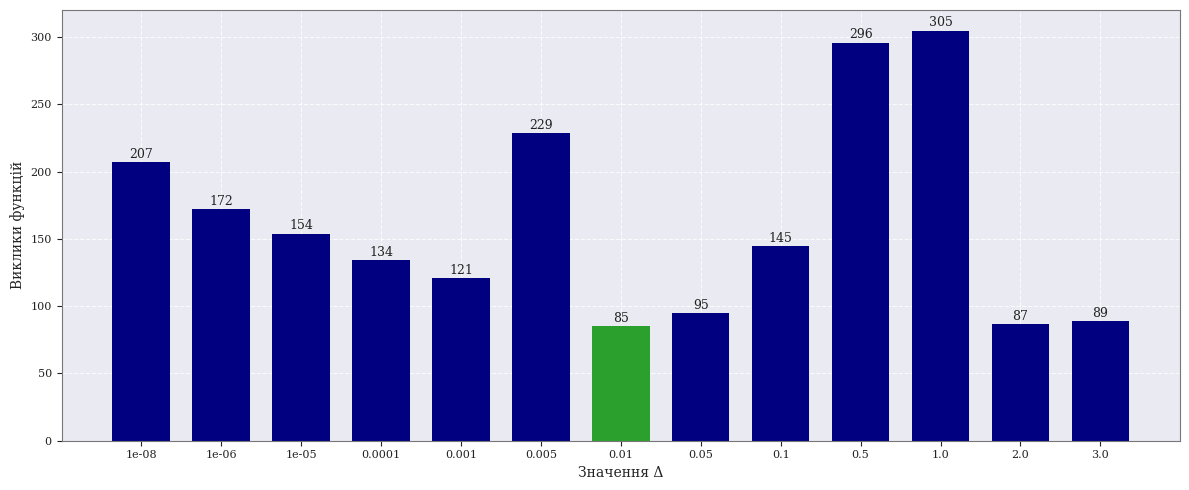

#### Вплив параметра Свена для МНС і ПАРТАН-МНС

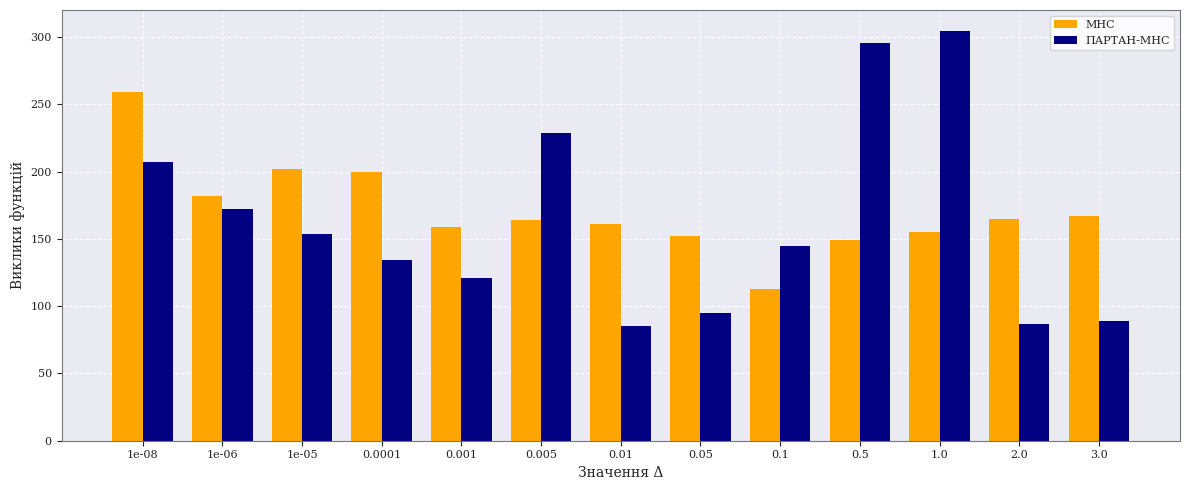

**Висновок.** Параметр Свена впливає на вартість локалізації інтервалу для одновимірного пошуку, тому кількість викликів функції може суттєво змінюватися.

In [42]:
sven_values = EXPERIMENTS["sven_alpha"]
sven_rows = []
for method_name, method_callable in METHODS.items():
    for alpha in sven_values:
        params = base_params.copy()
        params["sven_alpha"] = alpha
        result = method_callable(power_function, X_START, **params)
        sven_rows.append({
            "method": method_name,
            "sven_alpha": alpha,
            "func_calls": result["func_calls"],
            "iterations": result["iterations"],
            "status": result["status"],
        })
sven_alpha_table = pd.DataFrame(sven_rows)
show_table(sven_alpha_table.rename(columns={"sven_alpha": "\u0394"}))


main_method_name = "\u041f\u0410\u0420\u0422\u0410\u041d-\u041c\u041d\u0421"
main_sven_table = sven_alpha_table[sven_alpha_table["method"] == main_method_name].copy()
main_calls = main_sven_table["func_calls"].to_numpy(dtype=float)
min_calls = float(np.nanmin(main_calls))
bar_colors = ["tab:green" if np.isclose(value, min_calls) else "navy" for value in main_calls]
labels = [str(value) for value in main_sven_table["sven_alpha"]]

show_plot_heading("\u0412\u043f\u043b\u0438\u0432 \u0437\u043d\u0430\u0447\u0435\u043d\u043d\u044f \u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440\u0430 \u0432 \u0430\u043b\u0433\u043e\u0440\u0438\u0442\u043c\u0456 \u0421\u0432\u0435\u043d\u0430")
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, main_calls, color=bar_colors, width=0.72)
for bar, value in zip(bars, main_calls):
    ax.annotate(
        str(int(value)),
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )
ax.set_xlabel("\u0417\u043d\u0430\u0447\u0435\u043d\u043d\u044f \u0394")
ax.set_ylabel("\u0412\u0438\u043a\u043b\u0438\u043a\u0438 \u0444\u0443\u043d\u043a\u0446\u0456\u0439")
ax.grid(True, axis="y", linestyle="--", alpha=0.85)
plt.tight_layout()
plt.show()

show_plot_heading("\u0412\u043f\u043b\u0438\u0432 \u043f\u0430\u0440\u0430\u043c\u0435\u0442\u0440\u0430 \u0421\u0432\u0435\u043d\u0430 \u0434\u043b\u044f \u041c\u041d\u0421 \u0456 \u041f\u0410\u0420\u0422\u0410\u041d-\u041c\u041d\u0421")
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sven_values))
width = 0.38
method_colors = {"\u041c\u041d\u0421": "orange", "\u041f\u0410\u0420\u0422\u0410\u041d-\u041c\u041d\u0421": "navy"}
for offset_index, method_name in enumerate(METHODS):
    method_table = sven_alpha_table[sven_alpha_table["method"] == method_name].copy()
    method_table["sven_alpha"] = pd.Categorical(method_table["sven_alpha"], categories=sven_values, ordered=True)
    method_table = method_table.sort_values("sven_alpha")
    offset = (offset_index - (len(METHODS) - 1) / 2) * width
    ax.bar(
        x + offset,
        method_table["func_calls"].to_numpy(dtype=float),
        width=width,
        color=method_colors.get(method_name),
        label=method_name,
    )
ax.set_xticks(x)
ax.set_xticklabels([str(value) for value in sven_values], rotation=0)
ax.set_xlabel("\u0417\u043d\u0430\u0447\u0435\u043d\u043d\u044f \u0394")
ax.set_ylabel("\u0412\u0438\u043a\u043b\u0438\u043a\u0438 \u0444\u0443\u043d\u043a\u0446\u0456\u0439")
ax.grid(True, axis="y", linestyle="--", alpha=0.85)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown("**\u0412\u0438\u0441\u043d\u043e\u0432\u043e\u043a.** \u041f\u0430\u0440\u0430\u043c\u0435\u0442\u0440 \u0421\u0432\u0435\u043d\u0430 \u0432\u043f\u043b\u0438\u0432\u0430\u0454 \u043d\u0430 \u0432\u0430\u0440\u0442\u0456\u0441\u0442\u044c \u043b\u043e\u043a\u0430\u043b\u0456\u0437\u0430\u0446\u0456\u0457 \u0456\u043d\u0442\u0435\u0440\u0432\u0430\u043b\u0443 \u0434\u043b\u044f \u043e\u0434\u043d\u043e\u0432\u0438\u043c\u0456\u0440\u043d\u043e\u0433\u043e \u043f\u043e\u0448\u0443\u043a\u0443, \u0442\u043e\u043c\u0443 \u043a\u0456\u043b\u044c\u043a\u0456\u0441\u0442\u044c \u0432\u0438\u043a\u043b\u0438\u043a\u0456\u0432 \u0444\u0443\u043d\u043a\u0446\u0456\u0457 \u043c\u043e\u0436\u0435 \u0441\u0443\u0442\u0442\u0454\u0432\u043e \u0437\u043c\u0456\u043d\u044e\u0432\u0430\u0442\u0438\u0441\u044f."))


### 4.6. Вплив критерію зупинки

#### Початкові дані тесту

,параметр,значення
0,тест,4.6. Вплив критерію зупинки
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,критерій зупинки
6,значення змінного параметра,"gradient, combined"
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,значення параметра,кінцева точка,кінцеве значення функції,норма градієнта,відстань до точного мінімуму,кількість ітерацій,кількість викликів функції,статус
0,МНС,gradient,"[0.82664204, 0.81725265]",9.158e-07,2.916e-05,2.519e-01,4,82,збіжність
1,МНС,combined,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,5.190e-03,8,161,збіжність
2,ПАРТАН-МНС,gradient,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,9.044e-03,4,85,збіжність
3,ПАРТАН-МНС,combined,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,9.044e-03,4,85,збіжність


#### критерій зупинки -> кількість ітерацій

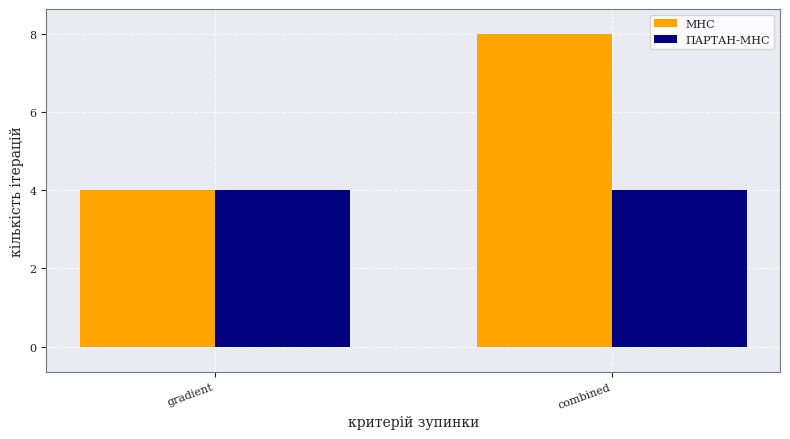

#### критерій зупинки -> кількість викликів функції

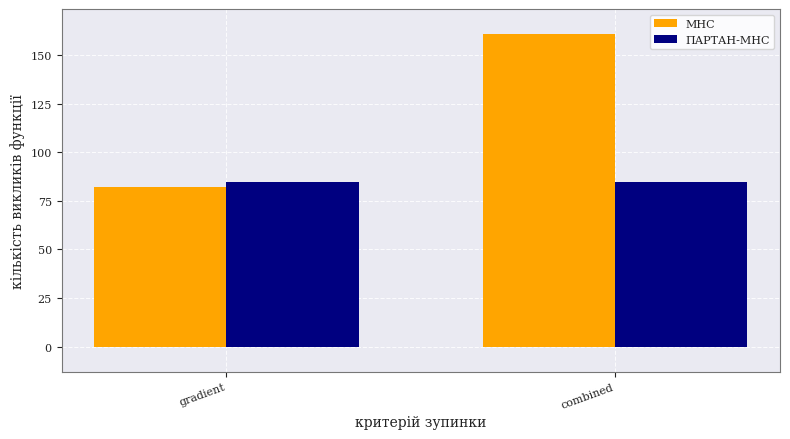

#### критерій зупинки -> відстань до точного мінімуму

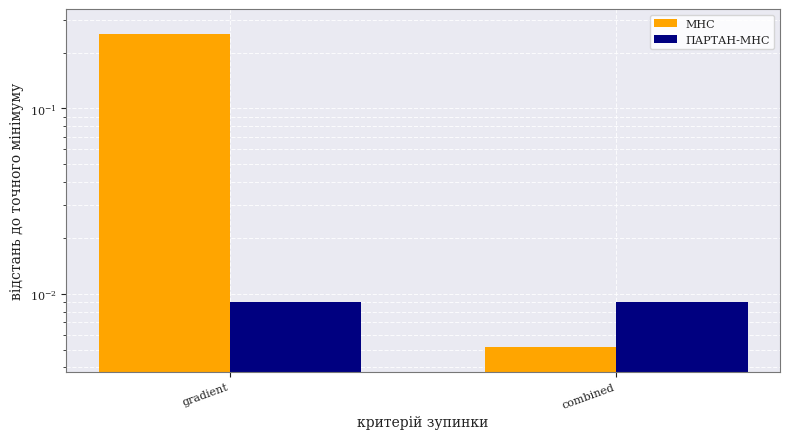

**Висновок.** Комбінований критерій враховує не тільки норму градієнта, але й зміну точки або значення функції, тому може бути практичнішим для чисельних методів.

In [43]:
stop_criterion_table = show_sweep("stop_criterion", "4.6. Вплив критерію зупинки")

### 4.7. Порівняння МНС і ПАРТАН-МНС

#### Початкові дані тесту

,параметр,значення
0,тест,Порівняння МНС і ПАРТАН-МНС
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,base_params[max_iter],1000
6,base_params[eps],0.001
7,base_params[derivative_h],0.001
8,base_params[gradient_scheme],central
9,base_params[line_search_method],dsk_powell


,метод,кінцева точка,кінцеве значення функції,норма градієнта,кількість ітерацій,кількість викликів функції,статус
0,МНС,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,8,161,збіжність
1,ПАРТАН-МНС,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,4,85,збіжність


#### Порівняння за кількістю ітерацій

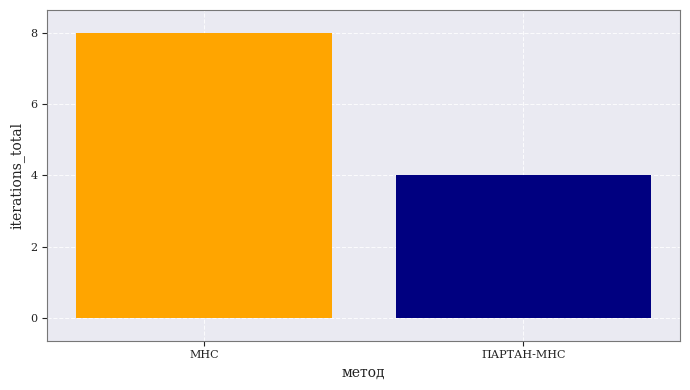

#### Порівняння за кількістю викликів функції

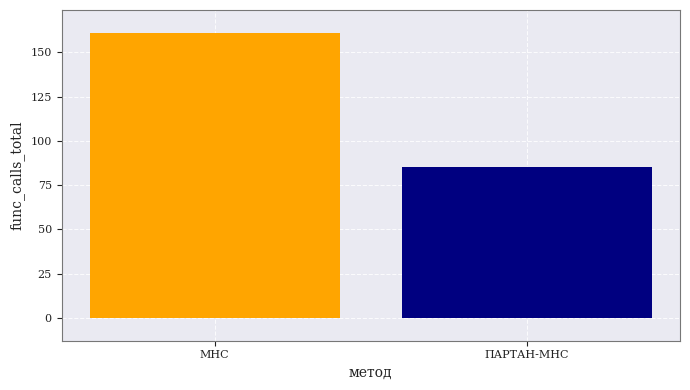

**Висновок.** Порівняння показує різницю між методами за кількістю ітерацій, викликів функції та точністю фінальної точки.

In [44]:
show_test_initial_data(
    "\u041f\u043e\u0440\u0456\u0432\u043d\u044f\u043d\u043d\u044f \u041c\u041d\u0421 \u0456 \u041f\u0410\u0420\u0422\u0410\u041d-\u041c\u041d\u0421",
    methods=list(METHODS),
    params=BASE_PARAMS,
)
comparison_table = compare_methods(BASE_PARAMS)
show_table(comparison_table)

fig, ax = plt.subplots(figsize=(7, 4))
plot_final_comparison(comparison_table.rename(columns={"iterations": "iterations_total"}), "iterations_total", "Порівняння за кількістю ітерацій", ax=ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
plot_final_comparison(comparison_table.rename(columns={"func_calls": "func_calls_total"}), "func_calls_total", "Порівняння за кількістю викликів функції", ax=ax)
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Порівняння показує різницю між методами за кількістю ітерацій, викликів функції та точністю фінальної точки."))

### 4.8. Траєкторії пошуку

#### Початкові дані тесту

,параметр,значення
0,тест,Траєкторії пошуку
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,джерело параметрів,ручні параметри з BEST_EXPERIMENT_PARAMS
6,base_params[max_iter],1000
7,base_params[eps],0.001
8,base_params[derivative_h],0.001
9,base_params[gradient_scheme],central


#### Ручно задані параметри для запуску траєкторій

,параметр,значення
0,крок h,0.001
1,схема чисельного диференціювання,central
2,метод одновимірного пошуку,dsk_powell
3,точність одновимірного пошуку,0.0
4,параметр α методу Свена,0.01
5,критерій зупинки,combined


#### Траєкторія пошуку МНС та ПАРТАН-МНС

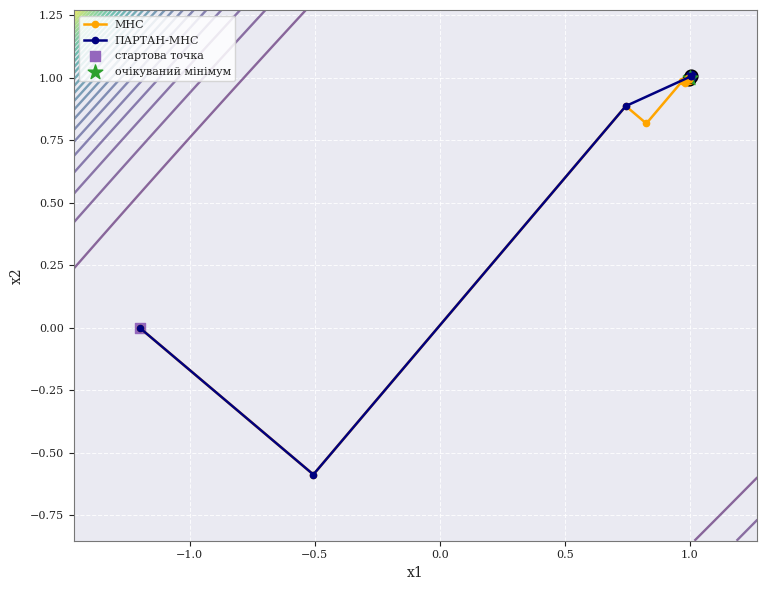

**Висновок.** Траєкторії побудовано з параметрами з BEST_EXPERIMENT_PARAMS (або з base_params, якщо словник порожній).

In [45]:
trajectory_params = build_tuned_params(base_params)

show_test_initial_data(
    "Траєкторії пошуку",
    methods=list(METHODS),
    params=trajectory_params,
    extra_rows=[
        {"parameter": "джерело параметрів", "value": "ручні параметри з BEST_EXPERIMENT_PARAMS"},
    ],
)
show_best_params_summary("Ручно задані параметри для запуску траєкторій")

mns_result = steepest_descent(power_function, X_START, **trajectory_params)
partan_result = partan_steepest_descent(power_function, X_START, **trajectory_params)
trajectory_results = {"МНС": mns_result, "ПАРТАН-МНС": partan_result}

plot_combined_trajectories(trajectory_results, "Траєкторія пошуку МНС та ПАРТАН-МНС")

display(Markdown("**Висновок.** Траєкторії побудовано з параметрами з BEST_EXPERIMENT_PARAMS (або з base_params, якщо словник порожній)."))


### 4.9. Графіки збіжності

#### Початкові дані тесту

,параметр,значення
0,тест,Графіки збіжності
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,джерело даних,результати з розділу 4.8
6,base_params[max_iter],1000
7,base_params[eps],0.001
8,base_params[derivative_h],0.001
9,base_params[gradient_scheme],central


#### Збіжність значення функції для МНС і ПАРТАН-МНС

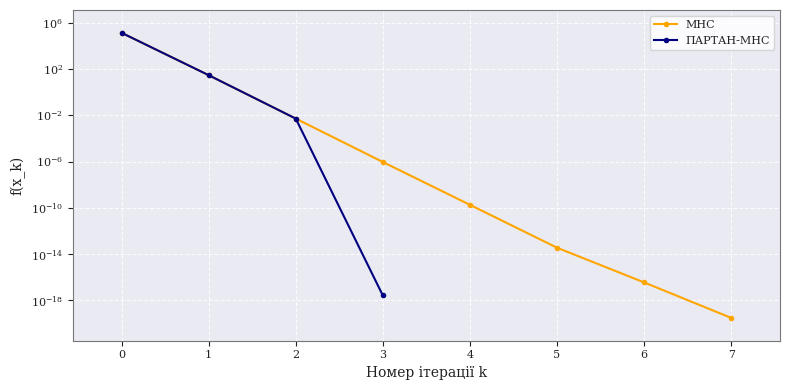

#### Зміна норми градієнта в процесі мінімізації

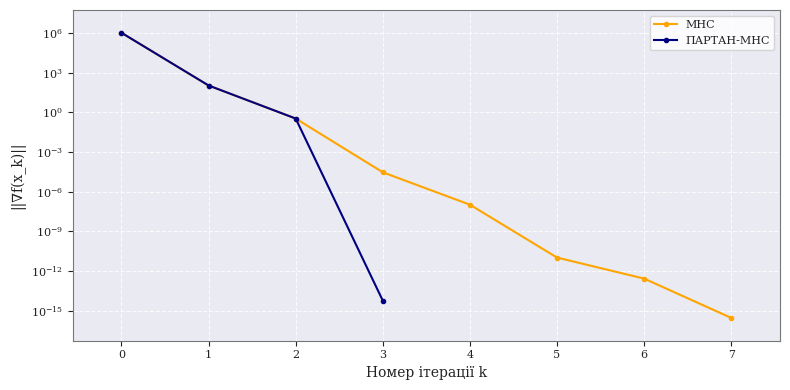

#### Накопичена кількість викликів функції під час мінімізації

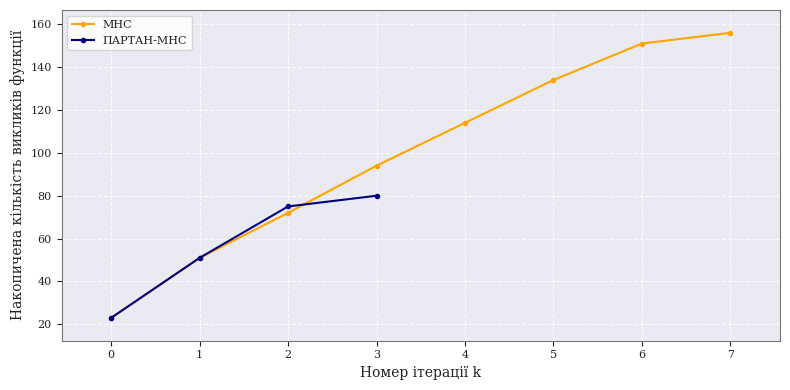

**Висновок.** Графіки збіжності показують, який метод швидше зменшує значення функції та норму градієнта. Накопичена кількість викликів функції демонструє обчислювальну вартість кожного кроку: якщо ПАРТАН-МНС робить менше ітерацій, але кожна ітерація дорожча, це видно на цьому графіку.

In [46]:
show_test_initial_data(
    "\u0413\u0440\u0430\u0444\u0456\u043a\u0438 \u0437\u0431\u0456\u0436\u043d\u043e\u0441\u0442\u0456",
    methods=list(trajectory_results),
    extra_rows=[{"parameter": "\u0434\u0436\u0435\u0440\u0435\u043b\u043e \u0434\u0430\u043d\u0438\u0445", "value": "\u0440\u0435\u0437\u0443\u043b\u044c\u0442\u0430\u0442\u0438 \u0437 \u0440\u043e\u0437\u0434\u0456\u043b\u0443 4.8"}],
)
fig, ax = plt.subplots(figsize=(8, 4))
plot_convergence_by_iteration(trajectory_results, "Збіжність значення функції для МНС і ПАРТАН-МНС", ax=ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_gradient_norm_by_iteration(trajectory_results, "Зміна норми градієнта в процесі мінімізації", ax=ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_cumulative_calls_by_iteration(trajectory_results, "Накопичена кількість викликів функції під час мінімізації", ax=ax)
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Графіки збіжності показують, який метод швидше зменшує значення функції та норму градієнта. Накопичена кількість викликів функції демонструє обчислювальну вартість кожного кроку: якщо ПАРТАН-МНС робить менше ітерацій, але кожна ітерація дорожча, це видно на цьому графіку."))

## 5. Умовна оптимізація методом штрафних функцій

### 5.1. Пояснення методу

Метод штрафних функцій дозволяє розв’язувати задачу умовної оптимізації через послідовність задач безумовної оптимізації.

Початкова задача має вигляд:

`min f(x), при g(x) <= 0`.

Для цього будується допоміжна функція:

`F(x, r) = f(x) + r * P(x)`,

де `P(x)` — штраф за порушення обмеження.

У роботі використовується зовнішня штрафна функція:

`P(x) = max(0, g(x))^2`.

Якщо точка знаходиться всередині допустимої області, штраф дорівнює нулю. Якщо точка виходить за межі області, штраф зростає.

Конкретне обмеження:

`g(x) = x1^2 + x2^2 - 1 <= 0`.

### 5.2. Вплив коефіцієнта штрафу r

#### Початкові дані тесту

,параметр,значення
0,тест,Вплив коефіцієнта штрафу r
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,r
6,значення змінного параметра,"1, 10, 100, 1000, 10000, 100000"
7,обмеження,x1^2 + x2^2 - 1 <= 0
8,base_params[max_iter],1000
9,base_params[eps],0.001


#### МНС

,початкова точка,коефіцієнт штрафу r,кінцева точка,значення початкової функції,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,кількість ітерацій,кількість викликів функції,статус
0,"[-1.20000000, 0.00000000]",1,"[0.71427503, 0.70003412]",4.900e-05,4.906e-05,2.366e-04,2.366e-04,1.183e-04,1000,18221,ліміт ітерацій
1,"[-1.20000000, 0.00000000]",10,"[0.71423440, 0.69992351]",4.910e-05,4.911e-05,2.370e-05,2.370e-05,1.185e-05,1000,20652,ліміт ітерацій
2,"[-1.20000000, 0.00000000]",100,"[0.71423062, 0.69991213]",4.911e-05,4.911e-05,2.371e-06,2.371e-06,1.185e-06,1000,35492,ліміт ітерацій
3,"[-1.20000000, 0.00000000]",1000,"[0.71403857, 0.69977944]",4.933e-05,4.933e-05,-4.577e-04,0.000e+00,2.289e-04,1000,162505,ліміт ітерацій
4,"[-1.20000000, 0.00000000]",10000,"[0.71314284, 0.70092521]",4.927e-05,4.927e-05,-1.311e-04,0.000e+00,6.557e-05,67,11042,збіжність
5,"[-1.20000000, 0.00000000]",100000,"[0.71308112, 0.70099306]",4.928e-05,4.928e-05,-1.240e-04,0.000e+00,6.202e-05,116,19154,збіжність


#### ПАРТАН-МНС

,початкова точка,коефіцієнт штрафу r,кінцева точка,значення початкової функції,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,кількість ітерацій,кількість викликів функції,статус
0,"[-1.20000000, 0.00000000]",1,"[0.71683631, 0.69742347]",4.967e-05,4.973e-05,2.538e-04,2.538e-04,1.269e-04,7,293,збіжність
1,"[-1.20000000, 0.00000000]",10,"[0.71436925, 0.69978598]",4.911e-05,4.911e-05,2.384e-05,2.384e-05,1.192e-05,7,406,збіжність
2,"[-1.20000000, 0.00000000]",100,"[0.70996473, 0.69636272]",5.463e-05,5.463e-05,-1.103e-02,0.000e+00,5.530e-03,1000,162437,ліміт ітерацій
3,"[-1.20000000, 0.00000000]",1000,"[0.70965477, 0.69675015]",5.461e-05,5.461e-05,-1.093e-02,0.000e+00,5.480e-03,3,347,збіжність
4,"[-1.20000000, 0.00000000]",10000,"[0.71080473, 0.70333114]",5.024e-05,5.024e-05,-8.193e-05,0.000e+00,4.097e-05,15,2895,збіжність
5,"[-1.20000000, 0.00000000]",100000,"[0.71204233, 0.70126273]",4.998e-05,4.998e-05,-1.226e-03,0.000e+00,6.133e-04,3,346,збіжність


#### r -> кількість ітерацій

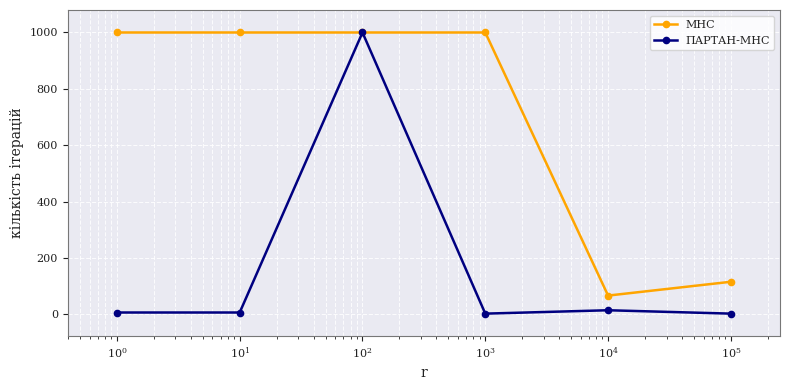

#### r -> кількість викликів функції

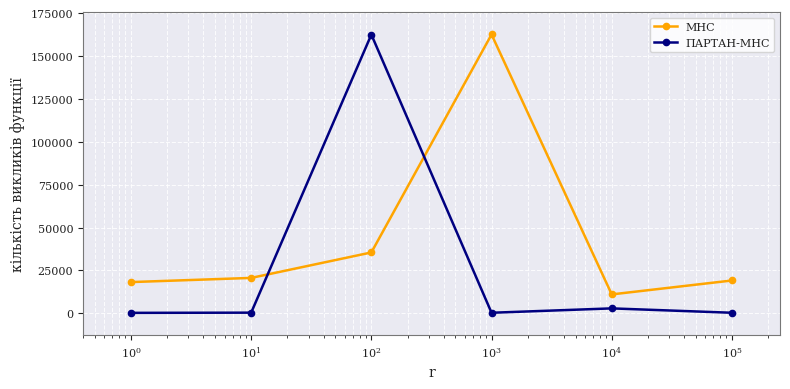

#### r -> порушення обмеження

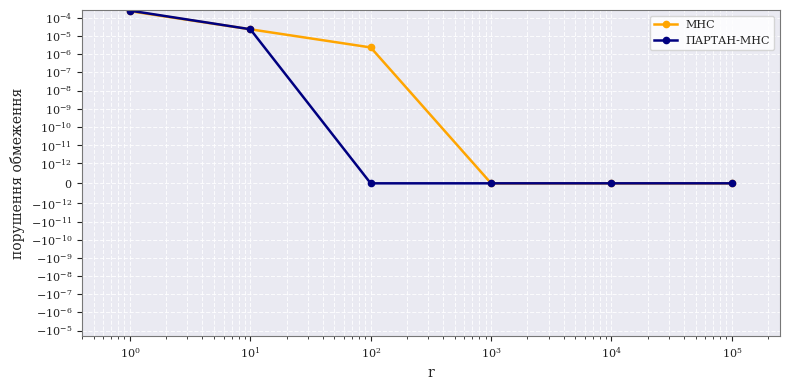

#### r -> значення g(x)

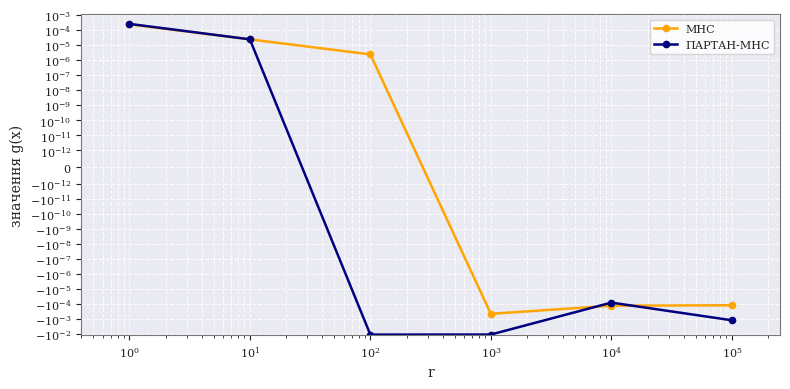

#### r -> значення початкової функції

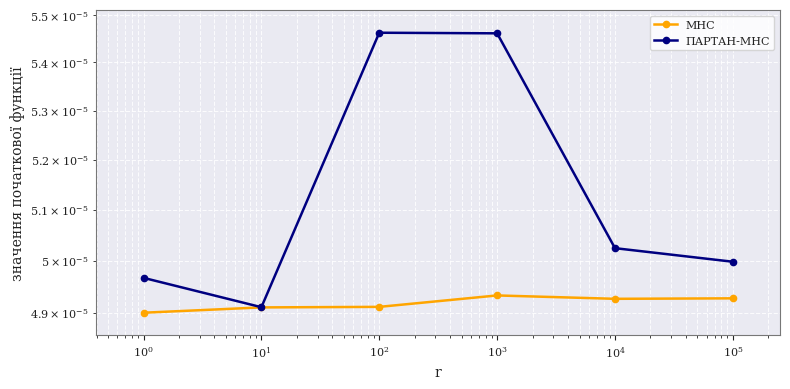

#### r -> значення штрафної функції

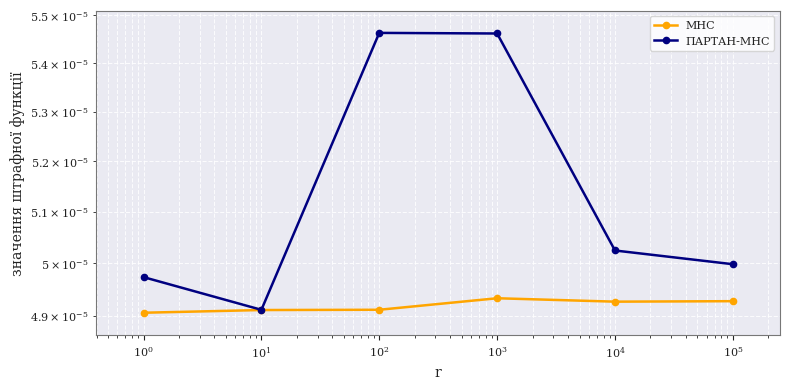

**Висновок.** При збільшенні коефіцієнта штрафу r порушення обмеження зменшується, але обчислювальна складність може зростати.

In [47]:
R_VALUES = (1, 10, 100, 1000, 10000, 100000)
penalty_base_params = build_tuned_params(BASE_PARAMS)
show_test_initial_data(
    "\u0412\u043f\u043b\u0438\u0432 \u043a\u043e\u0435\u0444\u0456\u0446\u0456\u0454\u043d\u0442\u0430 \u0448\u0442\u0440\u0430\u0444\u0443 r",
    varied_parameter="r",
    varied_values=R_VALUES,
    methods=list(METHODS),
    extra_rows=[{"parameter": "\u043e\u0431\u043c\u0435\u0436\u0435\u043d\u043d\u044f", "value": "x1^2 + x2^2 - 1 <= 0"}],
    params=penalty_base_params,
)
penalty_tables = compare_penalty_methods(base_params=penalty_base_params, r_values=R_VALUES)
penalty_long = pd.concat(
    [table.assign(method=method_name) for method_name, table in penalty_tables.items()],
    ignore_index=True,
)

for method_name, table in penalty_tables.items():
    display(Markdown(f"#### {method_name}"))
    show_table(table)

metrics = [
    ("iterations", "кількість ітерацій", False),
    ("func_calls", "кількість викликів функції", False),
    ("violation", "порушення обмеження", True),
    ("constraint_value", "значення g(x)", True),
    ("f_original", "значення початкової функції", True),
    ("F_penalty", "значення штрафної функції", True),
]
for metric, ylabel, log_y in metrics:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_metric_by_parameter(
        penalty_long,
        parameter_col="r",
        metric_col=metric,
        title=f"r -> {ylabel}",
        xlabel="r",
        ylabel=ylabel,
        log_x=True,
        log_y=log_y,
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

display(Markdown("**Висновок.** При збільшенні коефіцієнта штрафу r порушення обмеження зменшується, але обчислювальна складність може зростати."))

### 5.3. Порушення обмеження від r

#### Початкові дані тесту

,параметр,значення
0,тест,Порушення обмеження від r
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,r
6,значення змінного параметра,"1, 10, 100, 1000, 10000, 100000"
7,метрика на графіку,"violation = max(0, g(x))"
8,base_params[max_iter],1000
9,base_params[eps],0.001


#### Порушення обмеження залежно від r

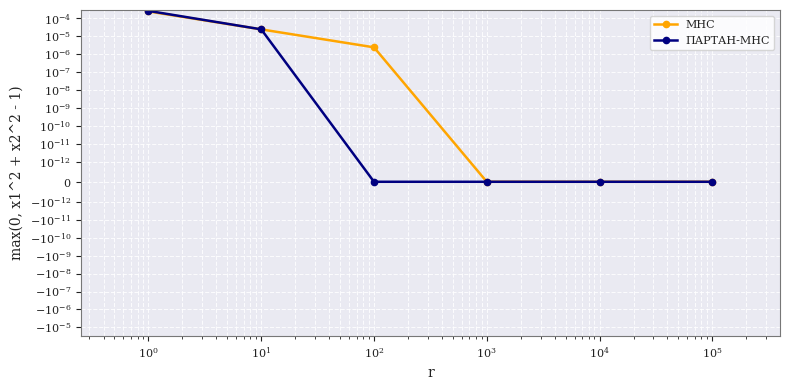

In [48]:
show_test_initial_data(
    "\u041f\u043e\u0440\u0443\u0448\u0435\u043d\u043d\u044f \u043e\u0431\u043c\u0435\u0436\u0435\u043d\u043d\u044f \u0432\u0456\u0434 r",
    varied_parameter="r",
    varied_values=R_VALUES,
    methods=list(penalty_tables),
    extra_rows=[{"parameter": "\u043c\u0435\u0442\u0440\u0438\u043a\u0430 \u043d\u0430 \u0433\u0440\u0430\u0444\u0456\u043a\u0443", "value": "violation = max(0, g(x))"}],
    params=penalty_base_params,
)
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_by_parameter(
    penalty_long,
    parameter_col="r",
    metric_col="violation",
    title="Порушення обмеження залежно від r",
    xlabel="r",
    ylabel="max(0, x1^2 + x2^2 - 1)",
    log_x=True,
    log_y=True,
    ax=ax,
)
apply_padded_axis_limits(
    ax,
    penalty_long["r"],
    penalty_long["violation"],
    x_log=True,
    y_log=ax.get_yscale() == "log",
)
plt.tight_layout()
plt.show()

### 5.4. Відстань до межі від r

#### Початкові дані тесту

,параметр,значення
0,тест,Відстань до межі від r
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,r
6,значення змінного параметра,"1, 10, 100, 1000, 10000, 100000"
7,метрика на графіку,abs(sqrt(x1^2 + x2^2) - 1)
8,base_params[max_iter],1000
9,base_params[eps],0.001


#### Відстань фінальної точки до межі області

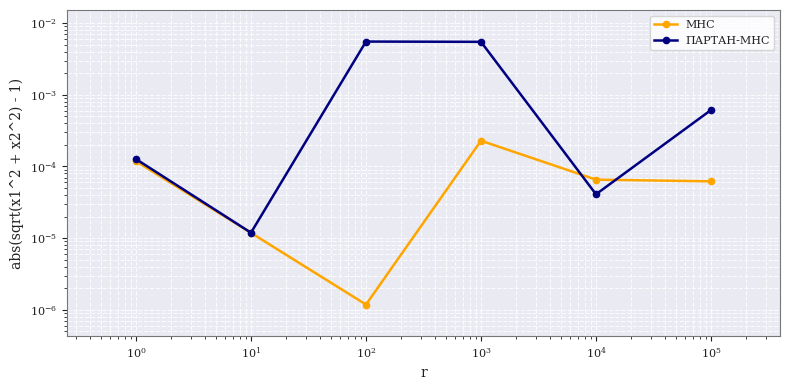

**Висновок.** Цей графік показує, наскільки близько фінальна точка знаходиться до межі допустимої області.

In [49]:
show_test_initial_data(
    "\u0412\u0456\u0434\u0441\u0442\u0430\u043d\u044c \u0434\u043e \u043c\u0435\u0436\u0456 \u0432\u0456\u0434 r",
    varied_parameter="r",
    varied_values=R_VALUES,
    methods=list(penalty_tables),
    extra_rows=[{"parameter": "\u043c\u0435\u0442\u0440\u0438\u043a\u0430 \u043d\u0430 \u0433\u0440\u0430\u0444\u0456\u043a\u0443", "value": "abs(sqrt(x1^2 + x2^2) - 1)"}],
    params=penalty_base_params,
)
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric_by_parameter(
    penalty_long,
    parameter_col="r",
    metric_col="distance_to_boundary",
    title="Відстань фінальної точки до межі області",
    xlabel="r",
    ylabel="abs(sqrt(x1^2 + x2^2) - 1)",
    log_x=True,
    log_y=True,
    ax=ax,
)
apply_padded_axis_limits(
    ax,
    penalty_long["r"],
    penalty_long["distance_to_boundary"],
    x_log=True,
    y_log=ax.get_yscale() == "log",
)
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Цей графік показує, наскільки близько фінальна точка знаходиться до межі допустимої області."))

### 5.5. Координати фінальної точки від r

#### Початкові дані тесту

,параметр,значення
0,тест,Координати фінальної точки від r
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,r
6,значення змінного параметра,"1, 10, 100, 1000, 10000, 100000"
7,метрики на графіку,"x1_final, x2_final"
8,base_params[max_iter],1000
9,base_params[eps],0.001


#### Координати фінальної точки залежно від r

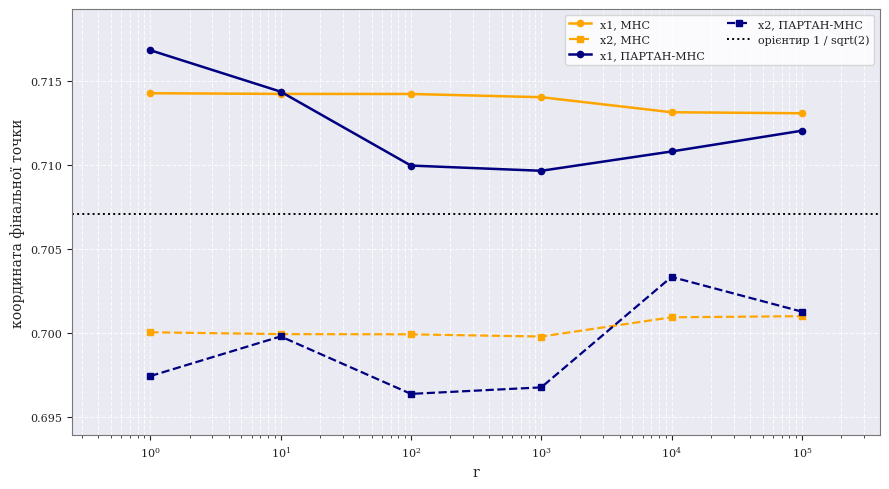

**Висновок.** Лінія `1 / sqrt(2)` використовується лише як орієнтир для точки на межі області в напрямку `(1; 1)`. Фактична фінальна точка визначається мінімумом заданої функції на межі круга, тому її координати не зобов’язані бути однаковими.

In [50]:
show_test_initial_data(
    "\u041a\u043e\u043e\u0440\u0434\u0438\u043d\u0430\u0442\u0438 \u0444\u0456\u043d\u0430\u043b\u044c\u043d\u043e\u0457 \u0442\u043e\u0447\u043a\u0438 \u0432\u0456\u0434 r",
    varied_parameter="r",
    varied_values=R_VALUES,
    methods=list(penalty_tables),
    extra_rows=[{"parameter": "\u043c\u0435\u0442\u0440\u0438\u043a\u0438 \u043d\u0430 \u0433\u0440\u0430\u0444\u0456\u043a\u0443", "value": "x1_final, x2_final"}],
    params=penalty_base_params,
)
coordinate_rows = []
for method_name, table in penalty_tables.items():
    for record in table.to_dict("records"):
        point = parse_point(record["x_final"])
        coordinate_rows.append({"method": method_name, "r": record["r"], "x1_final": point[0], "x2_final": point[1]})
coordinate_table = pd.DataFrame(coordinate_rows)

fig, ax = plt.subplots(figsize=(9, 5))
coordinate_method_colors = {"МНС": "orange", "ПАРТАН-МНС": "navy"}
for method_name, group in coordinate_table.groupby("method", sort=False):
    coordinate_method_color = coordinate_method_colors.get(method_name, "black")
    ax.plot(group["r"], group["x1_final"], "o-", color=coordinate_method_color, linewidth=1.8, label=f"x1, {method_name}")
    ax.plot(group["r"], group["x2_final"], "s--", color=coordinate_method_color, linewidth=1.6, label=f"x2, {method_name}")
expected = 1 / np.sqrt(2)
ax.axhline(expected, color="black", linestyle=":", linewidth=1.4, label="орієнтир 1 / sqrt(2)")
ax.set_xscale("log")
ax.set_xlabel("r")
ax.set_ylabel("координата фінальної точки")
show_plot_heading("Координати фінальної точки залежно від r")
ax.grid(True, which="both", linestyle="--", alpha=0.85)
coordinate_y_values = coordinate_table[["x1_final", "x2_final"]].to_numpy(dtype=float).reshape(-1)
apply_padded_axis_limits(
    ax,
    coordinate_table["r"],
    coordinate_y_values,
    x_log=True,
    y_include=[expected],
)
ax.legend(ncol=2, loc="best")
plt.tight_layout()
plt.show()

display(Markdown("**Висновок.** Лінія `1 / sqrt(2)` використовується лише як орієнтир для точки на межі області в напрямку `(1; 1)`. Фактична фінальна точка визначається мінімумом заданої функції на межі круга, тому її координати не зобов’язані бути однаковими."))

### 5.6. Траєкторії штрафного методу

#### Початкові дані тесту

,параметр,значення
0,тест,Траєкторії штрафного методу
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,r
6,значення змінного параметра,10000
7,обмеження,x1^2 + x2^2 - 1 <= 0
8,base_params[max_iter],1000
9,base_params[eps],0.001


#### Траєкторія штрафного методу: МНС

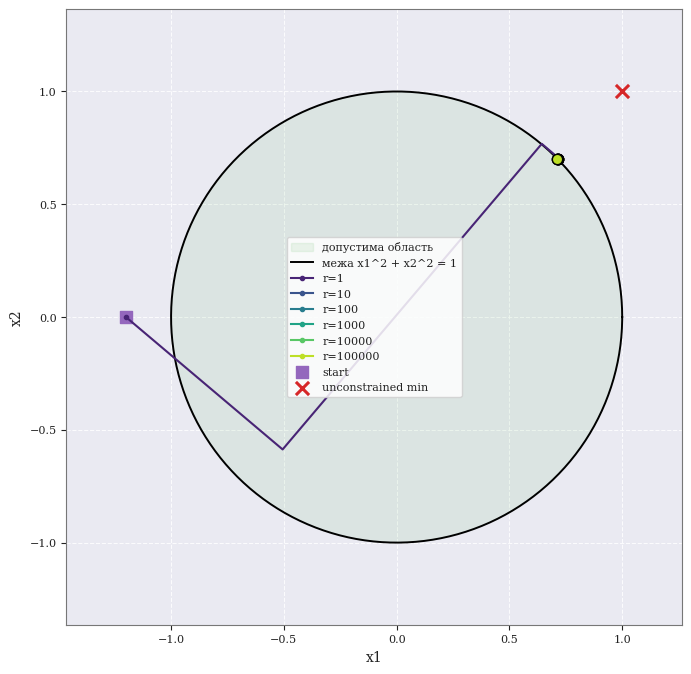

#### Траєкторія штрафного методу: ПАРТАН-МНС

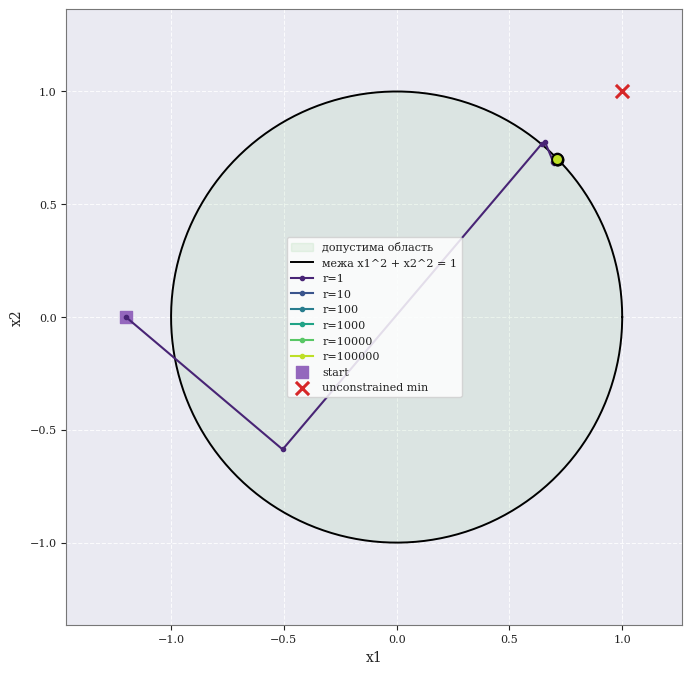

#### Порівняння траєкторій штрафного методу

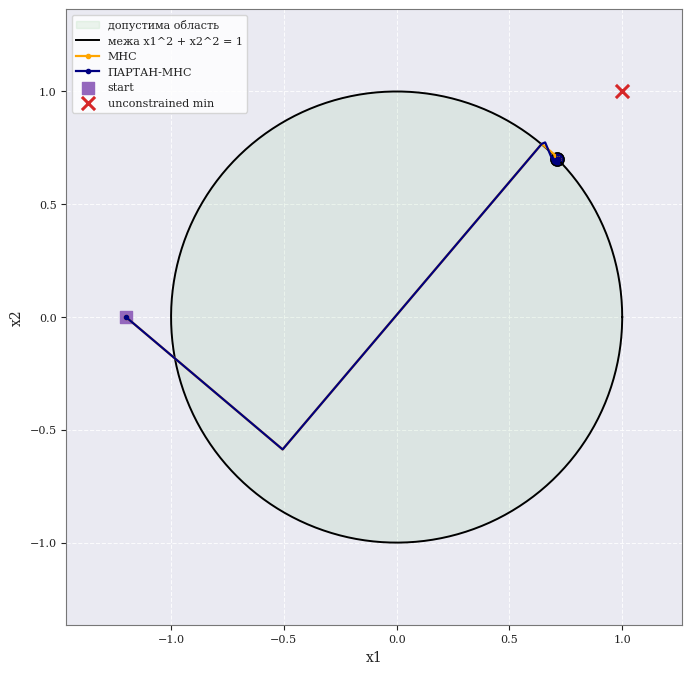

In [62]:
show_test_initial_data(
    "\u0422\u0440\u0430\u0454\u043a\u0442\u043e\u0440\u0456\u0457 \u0448\u0442\u0440\u0430\u0444\u043d\u043e\u0433\u043e \u043c\u0435\u0442\u043e\u0434\u0443",
    varied_parameter="r",
    varied_values=R_VALUES,
    methods=list(METHODS),
    extra_rows=[{"parameter": "\u043e\u0431\u043c\u0435\u0436\u0435\u043d\u043d\u044f", "value": "x1^2 + x2^2 - 1 <= 0"}],
    params=penalty_base_params,
)
def penalty_stage_trajectories(stage_callable, start_point, penalty_values, stage_params):
    current_point = np.asarray(start_point, dtype=float).reshape(-1)
    collected_stage_records = []
    for stage_value in penalty_values:
        penalty_function = make_external_penalty_function(power_function, [circle_constraint], stage_value)
        stage_result = stage_callable(penalty_function, current_point, **stage_params)
        stage_path = np.asarray(stage_result["points"], dtype=float)
        collected_stage_records.append((stage_value, stage_path))
        current_point = np.asarray(stage_result["x_final"], dtype=float).reshape(-1)
    return collected_stage_records


stage_method_map = METHODS
stage_color_values = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(R_VALUES)))

for stage_method_name, stage_callable in stage_method_map.items():
    fig, ax = plt.subplots(figsize=(7, 7))
    plot_circle_constraint(ax)
    method_stage_records = penalty_stage_trajectories(stage_callable, X_START, R_VALUES, penalty_base_params)
    method_limit_points = [np.asarray(X_START, dtype=float).reshape(1, 2), np.array([[1.0, 1.0]], dtype=float)]
    for stage_record, stage_color in zip(method_stage_records, stage_color_values):
        stage_value, stage_path = stage_record
        mark_every = max(1, len(stage_path) // 18)
        ax.plot(
            stage_path[:, 0],
            stage_path[:, 1],
            "-o",
            color=stage_color,
            linewidth=1.5,
            markersize=3,
            markevery=mark_every,
            label=f"r={stage_value}",
        )
        ax.scatter(stage_path[-1, 0], stage_path[-1, 1], s=55, color=stage_color, edgecolor="black", zorder=5)
        method_limit_points.append(stage_path)
    ax.scatter([X_START[0]], [X_START[1]], marker="s", s=70, color="tab:purple", label="start")
    ax.scatter([1.0], [1.0], marker="x", s=90, color="tab:red", linewidths=2.2, label="unconstrained min")
    show_plot_heading(f"\u0422\u0440\u0430\u0454\u043a\u0442\u043e\u0440\u0456\u044f \u0448\u0442\u0440\u0430\u0444\u043d\u043e\u0433\u043e \u043c\u0435\u0442\u043e\u0434\u0443: {stage_method_name}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    apply_equal_data_limits(ax, np.vstack(method_limit_points), include_unit_circle=True)
    ax.grid(True, linestyle="--", alpha=0.85)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
plot_circle_constraint(ax)
combined_color_by_method = {"МНС": "orange", "ПАРТАН-МНС": "navy"}
combined_limit_points = [np.asarray(X_START, dtype=float).reshape(1, 2), np.array([[1.0, 1.0]], dtype=float)]
for combined_method_name, combined_callable in stage_method_map.items():
    combined_records = penalty_stage_trajectories(combined_callable, X_START, R_VALUES, penalty_base_params)
    combined_path = np.vstack(
        [path_part if record_index == 0 else path_part[1:] for record_index, (_, path_part) in enumerate(combined_records)]
    )
    mark_every = max(1, len(combined_path) // 25)
    ax.plot(
        combined_path[:, 0],
        combined_path[:, 1],
        "-o",
        linewidth=1.6,
        markersize=3,
        markevery=mark_every,
        color=combined_color_by_method[combined_method_name],
        label=combined_method_name,
    )
    ax.scatter(
        combined_path[-1, 0],
        combined_path[-1, 1],
        s=90,
        color=combined_color_by_method[combined_method_name],
        edgecolor="black",
        linewidth=1.0,
    )
    combined_limit_points.append(combined_path)
ax.scatter([X_START[0]], [X_START[1]], marker="s", s=70, color="tab:purple", label="start")
ax.scatter([1.0], [1.0], marker="x", s=90, color="tab:red", linewidths=2.2, label="unconstrained min")
show_plot_heading("\u041f\u043e\u0440\u0456\u0432\u043d\u044f\u043d\u043d\u044f \u0442\u0440\u0430\u0454\u043a\u0442\u043e\u0440\u0456\u0439 \u0448\u0442\u0440\u0430\u0444\u043d\u043e\u0433\u043e \u043c\u0435\u0442\u043e\u0434\u0443")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
apply_equal_data_limits(ax, np.vstack(combined_limit_points), include_unit_circle=True)
ax.grid(True, linestyle="--", alpha=0.85)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.7. Вплив початкової точки

#### Початкові дані тесту

,параметр,значення
0,тест,Вплив початкової точки
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,x_start
6,значення змінного параметра,"[-1.50000000, 0.00000000], [1.50000000, 0.0000..."
7,значення r,"1, 10, 100, 1000, 10000"
8,base_params[max_iter],1000
9,base_params[eps],0.001


,метод,початкова точка,кінцева точка,значення початкової функції,значення обмеження g(x),порушення обмеження,відстань до межі області,сумарна кількість ітерацій,сумарна кількість викликів функції,статус
0,МНС,"[-1.50000000, 0.00000000]","[0.71314284, 0.70092521]",4.927e-05,-1.311e-04,0.000e+00,6.557e-05,4067,248045,"ліміт ітерацій, збіжність"
1,МНС,"[1.50000000, 0.00000000]","[0.71314284, 0.70092521]",4.927e-05,-1.311e-04,0.000e+00,6.557e-05,4067,247824,"ліміт ітерацій, збіжність"
2,МНС,"[0.00000000, 1.50000000]","[0.71314284, 0.70092521]",4.927e-05,-1.311e-04,0.000e+00,6.557e-05,4067,247840,"ліміт ітерацій, збіжність"
3,МНС,"[-1.00000000, -1.00000000]","[0.71314524, 0.70092375]",4.927e-05,-1.298e-04,0.000e+00,6.488e-05,4066,247880,"ліміт ітерацій, збіжність"
4,МНС,"[2.00000000, 2.00000000]","[0.71314524, 0.70092375]",4.927e-05,-1.298e-04,0.000e+00,6.488e-05,4066,247783,"ліміт ітерацій, збіжність"
5,ПАРТАН-МНС,"[-1.50000000, 0.00000000]","[0.71483761, 0.69910789]",4.930e-05,-2.554e-04,0.000e+00,1.277e-04,31,2722,збіжність
6,ПАРТАН-МНС,"[1.50000000, 0.00000000]","[0.71481898, 0.69914380]",4.928e-05,-2.318e-04,0.000e+00,1.159e-04,26,2302,збіжність
7,ПАРТАН-МНС,"[0.00000000, 1.50000000]","[0.71665865, 0.69731475]",4.984e-05,-1.525e-04,0.000e+00,7.627e-05,30,2815,збіжність
8,ПАРТАН-МНС,"[-1.00000000, -1.00000000]","[0.71668671, 0.69729129]",4.985e-05,-1.450e-04,0.000e+00,7.252e-05,36,3113,збіжність
9,ПАРТАН-МНС,"[2.00000000, 2.00000000]","[0.71666211, 0.69731186]",4.985e-05,-1.516e-04,0.000e+00,7.580e-05,32,2848,збіжність


#### Початкова точка -> сумарна кількість ітерацій

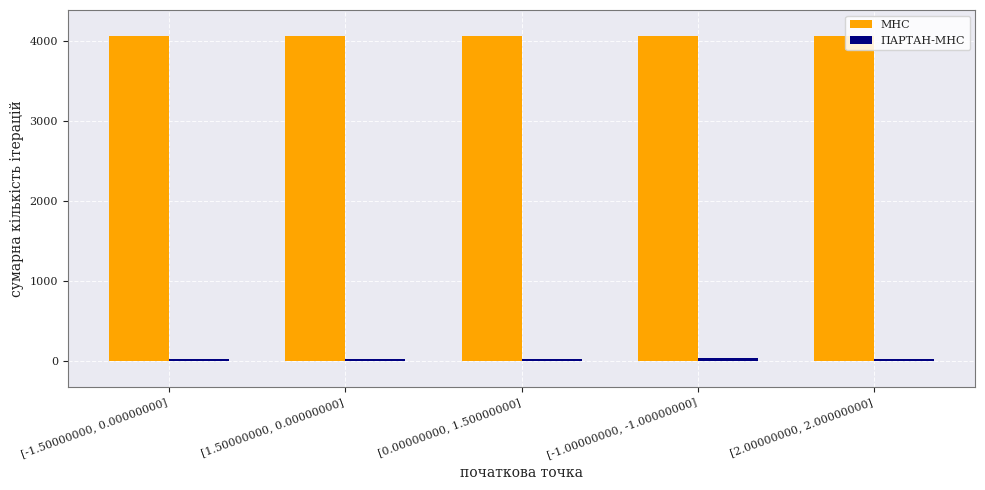

#### Початкова точка -> сумарна кількість викликів функції

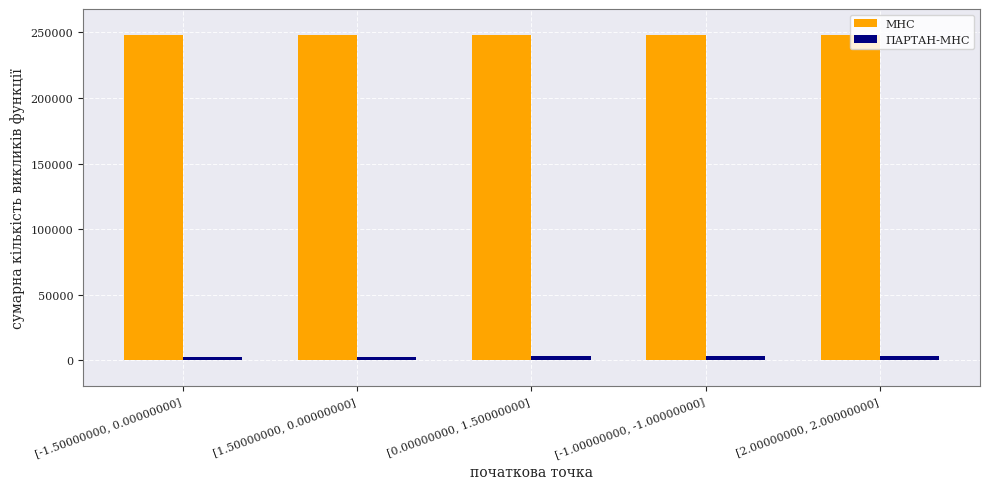

TypeError: 'int' object is not iterable

In [58]:
penalty_start_points = [
    [-1.5, 0.0],
    [1.5, 0.0],
    [0.0, 1.5],
    [-1.0, -1.0],
    [2.0, 2.0],
]
show_test_initial_data(
    "\u0412\u043f\u043b\u0438\u0432 \u043f\u043e\u0447\u0430\u0442\u043a\u043e\u0432\u043e\u0457 \u0442\u043e\u0447\u043a\u0438",
    varied_parameter="x_start",
    varied_values=[format_vector(point) for point in penalty_start_points],
    methods=list(METHODS),
    extra_rows=[{"parameter": "\u0437\u043d\u0430\u0447\u0435\u043d\u043d\u044f r", "value": "1, 10, 100, 1000, 10000"}],
    params=penalty_base_params,
)
start_point_table = compare_penalty_start_points(
    base_params=penalty_base_params,
    start_points=penalty_start_points,
    r_values=(1, 10, 100, 1000, 10000),
)
show_table(start_point_table)

start_plot_table = start_point_table.copy()
start_plot_table["start_label"] = start_plot_table["x_start"]
for start_metric_name, start_y_label in [
    ("iterations_total", "\u0441\u0443\u043c\u0430\u0440\u043d\u0430 \u043a\u0456\u043b\u044c\u043a\u0456\u0441\u0442\u044c \u0456\u0442\u0435\u0440\u0430\u0446\u0456\u0439"),
    ("func_calls_total", "\u0441\u0443\u043c\u0430\u0440\u043d\u0430 \u043a\u0456\u043b\u044c\u043a\u0456\u0441\u0442\u044c \u0432\u0438\u043a\u043b\u0438\u043a\u0456\u0432 \u0444\u0443\u043d\u043a\u0446\u0456\u0457"),
]:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_metric_by_parameter(
        start_plot_table,
        parameter_col="start_label",
        metric_col=start_metric_name,
        title=f"\u041f\u043e\u0447\u0430\u0442\u043a\u043e\u0432\u0430 \u0442\u043e\u0447\u043a\u0430 -> {start_y_label}",
        xlabel="\u043f\u043e\u0447\u0430\u0442\u043a\u043e\u0432\u0430 \u0442\u043e\u0447\u043a\u0430",
        ylabel=start_y_label,
        log_y=False,
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

def penalty_optimization_points(start_callable, start_point, penalty_values, optimization_params):
    current_point = np.asarray(start_point, dtype=float).reshape(-1)
    collected_path = []
    for penalty_value in penalty_values:
        penalty_function = make_external_penalty_function(power_function, [circle_constraint], penalty_value)
        penalty_result = start_callable(penalty_function, current_point, **optimization_params)
        current_path = np.asarray(penalty_result["points"], dtype=float)
        if collected_path:
            current_path = current_path[1:]
        collected_path.extend(current_path)
        current_point = np.asarray(penalty_result["x_final"], dtype=float).reshape(-1)
    return np.vstack(collected_path)


trajectory_r_values = (1, 10, 100, 1000, 10000)
start_points_array = np.array(penalty_start_points, dtype=float)
start_color_values = plt.get_cmap("tab10")(np.linspace(0, 1, len(start_points_array)))

for start_method_name, start_callable in METHODS.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_circle_constraint(ax)
    for start_index, (candidate_point, point_color) in enumerate(zip(start_points_array, start_color_values), start=1):
        trajectory_path = penalty_optimization_points(start_callable, candidate_point, trajectory_r_values, penalty_base_params)
        mark_every = max(1, len(trajectory_path) // 20)
        ax.plot(
            trajectory_path[:, 0],
            trajectory_path[:, 1],
            "-o",
            color=point_color,
            linewidth=1.4,
            markersize=3,
            markevery=mark_every,
            alpha=0.85,
            label=f"s{start_index}",
        )
        ax.scatter(trajectory_path[0, 0], trajectory_path[0, 1], marker="s", s=65, color=point_color, edgecolor="black", zorder=6)
        ax.scatter(trajectory_path[-1, 0], trajectory_path[-1, 1], marker="*", s=110, color=point_color, edgecolor="black", zorder=7)
        ax.annotate(f"s{start_index}", trajectory_path[0] + np.array([0.04, 0.04]), fontsize=9)
    ax.scatter([1], [1], marker="x", s=90, color="red", label="unconstrained min", zorder=8)
    show_plot_heading(f"\u0422\u0440\u0430\u0454\u043a\u0442\u043e\u0440\u0456\u0457 \u0448\u0442\u0440\u0430\u0444\u043d\u043e\u0433\u043e \u043c\u0435\u0442\u043e\u0434\u0443: {start_method_name}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

display(Markdown("**Conclusion.** The starting point mainly changes the computational cost: iterations and function calls. The trajectories show the internal path of the penalty method toward the active boundary region."))

### 5.8. Порівняння МНС і ПАРТАН-МНС для штрафної функції

#### Початкові дані тесту

,параметр,значення
0,тест,Порівняння МНС і ПАРТАН-МНС для штрафної функції
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"МНС, ПАРТАН-МНС"
5,змінний параметр,r
6,значення змінного параметра,100000
7,base_params[max_iter],1000
8,base_params[eps],0.001
9,base_params[derivative_h],0.001


,метод,фінальний коефіцієнт штрафу r,кінцева точка,значення початкової функції,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,сумарна кількість ітерацій,сумарна кількість викликів функції,статус
0,МНС,100000,"[0.71308112, 0.70099306]",4.928e-05,4.928e-05,-1.240e-04,0.000e+00,6.202e-05,4183,267066,"ліміт ітерацій, збіжність"
1,ПАРТАН-МНС,100000,"[0.71204233, 0.70126273]",4.998e-05,4.998e-05,-1.226e-03,0.000e+00,6.133e-04,1035,166724,"збіжність, ліміт ітерацій"


#### Порівняння за сумарною кількістю ітерацій

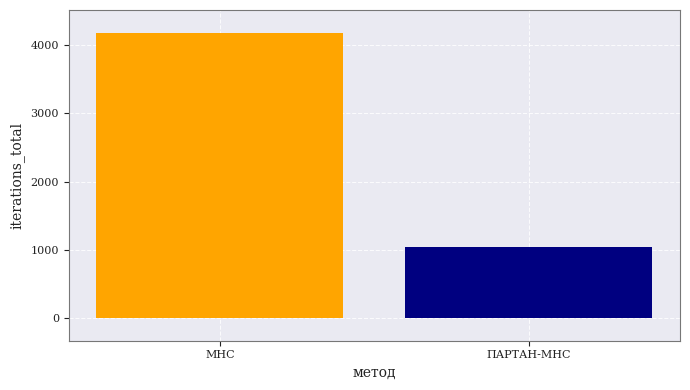

#### Порівняння за сумарною кількістю викликів

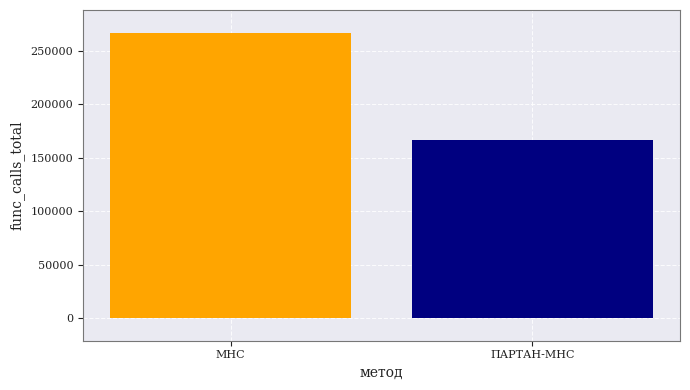

#### Порівняння за відстанню до межі

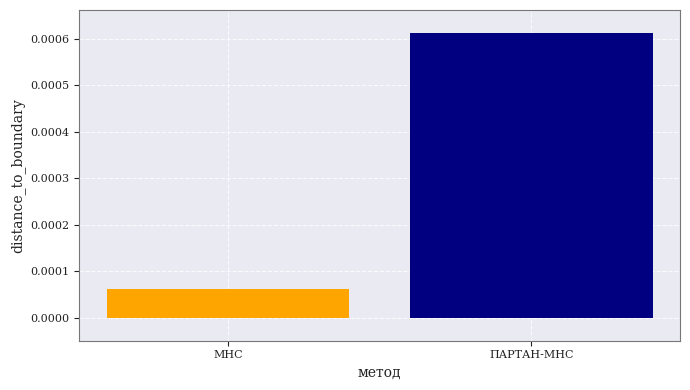

**Висновок.** Порівняння показує, який метод швидше розв'язує штрафну задачу та який метод дає менше порушення обмеження.

In [53]:
show_test_initial_data(
    "\u041f\u043e\u0440\u0456\u0432\u043d\u044f\u043d\u043d\u044f \u041c\u041d\u0421 \u0456 \u041f\u0410\u0420\u0422\u0410\u041d-\u041c\u041d\u0421 \u0434\u043b\u044f \u0448\u0442\u0440\u0430\u0444\u043d\u043e\u0457 \u0444\u0443\u043d\u043a\u0446\u0456\u0457",
    varied_parameter="r",

    varied_values=R_VALUES,
    methods=list(penalty_tables),
    params=penalty_base_params,
)
penalty_summary = pd.DataFrame([
    penalty_experiment_summary(table, method=method_name)
    for method_name, table in penalty_tables.items()
])
show_table(penalty_summary)

for metric, title in [
    ("iterations_total", "Порівняння за сумарною кількістю ітерацій"),
    ("func_calls_total", "Порівняння за сумарною кількістю викликів"),
    ("distance_to_boundary", "Порівняння за відстанню до межі"),
]:
    fig, ax = plt.subplots(figsize=(7, 4))
    plot_final_comparison(penalty_summary, metric, title, ax=ax)
    plt.tight_layout()
    plt.show()

display(Markdown("**Висновок.** Порівняння показує, який метод швидше розв'язує штрафну задачу та який метод дає менше порушення обмеження."))

## 6. Фінальне порівняння

In [54]:
unconstrained_final = comparison_table.copy()
unconstrained_final["task"] = "безумовна оптимізація"
unconstrained_final["r_final"] = "-"
unconstrained_final["F_penalty"] = "-"
unconstrained_final["constraint_value"] = "-"
unconstrained_final["violation"] = "-"
unconstrained_final["distance_to_boundary"] = "-"
unconstrained_final["iterations_total"] = unconstrained_final["iterations"]
unconstrained_final["func_calls_total"] = unconstrained_final["func_calls"]

penalty_final = penalty_summary.copy()
penalty_final["task"] = "штрафна функція"
penalty_final["f_final"] = penalty_final["f_original"]
penalty_final["grad_norm_final"] = "-"

final_comparison = pd.concat([
    unconstrained_final[["task", "method", "r_final", "x_final", "f_final", "grad_norm_final", "F_penalty", "constraint_value", "violation", "distance_to_boundary", "iterations_total", "func_calls_total", "status"]],
    penalty_final[["task", "method", "r_final", "x_final", "f_final", "grad_norm_final", "F_penalty", "constraint_value", "violation", "distance_to_boundary", "iterations_total", "func_calls_total", "status"]],
], ignore_index=True)

show_table(final_comparison)

,задача,метод,фінальний коефіцієнт штрафу r,кінцева точка,кінцеве значення функції,норма градієнта,значення штрафної функції,значення обмеження g(x),порушення обмеження,відстань до межі області,сумарна кількість ітерацій,сумарна кількість викликів функції,статус
0,безумовна оптимізація,МНС,-,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,-,-,-,-,8,161,збіжність
1,безумовна оптимізація,ПАРТАН-МНС,-,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,-,-,-,-,4,85,збіжність
2,штрафна функція,МНС,100000,"[0.71308112, 0.70099306]",4.928e-05,-,4.928e-05,-1.240e-04,0.000e+00,6.202e-05,4183,267066,"ліміт ітерацій, збіжність"
3,штрафна функція,ПАРТАН-МНС,100000,"[0.71204233, 0.70126273]",4.998e-05,-,4.998e-05,-1.226e-03,0.000e+00,6.133e-04,1035,166724,"збіжність, ліміт ітерацій"


## 7. Контроль через старі SymPy-версії

Цей блок потрібен лише для перевірки траєкторій. Старі реалізації використовують аналітичні похідні та точний пошук кроку через SymPy, тому кількість ітерацій обмежена.

#### Початкові дані тесту

,параметр,значення
0,тест,Контроль через старі SymPy-версії
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"MNS NumPy, MNS SymPy, PARTAN-MNS NumPy, PARTAN..."
5,контрольний max_iter,10
6,base_params[max_iter],1000
7,base_params[eps],0.001
8,base_params[derivative_h],0.001
9,base_params[gradient_scheme],central


,метод,кінцева точка,кінцеве значення функції,норма градієнта,кількість ітерацій,кількість викликів функції,статус,джерело
0,МНС,"[0.99644599, 0.99621754]",2.993e-20,2.765e-16,8,161,збіжність,поточна NumPy-версія
1,ПАРТАН-МНС,"[1.00632041, 1.00646839]",2.603e-18,5.578e-15,4,85,збіжність,поточна NumPy-версія
2,МНС SymPy,"[0.96765818, 0.98529917]",2.989e-10,1.572e-07,5,-,контроль,стара SymPy-версія
3,ПАРТАН-МНС SymPy,"[1.00343168, 1.00155986]",4.803e-18,2.380e-14,4,-,контроль,стара SymPy-версія


#### Контрольна траєкторія МНС (SymPy)

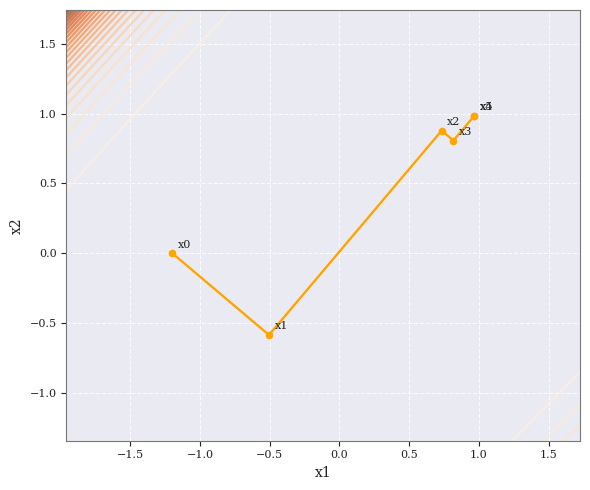

#### Контрольна траєкторія ПАРТАН-МНС (SymPy)

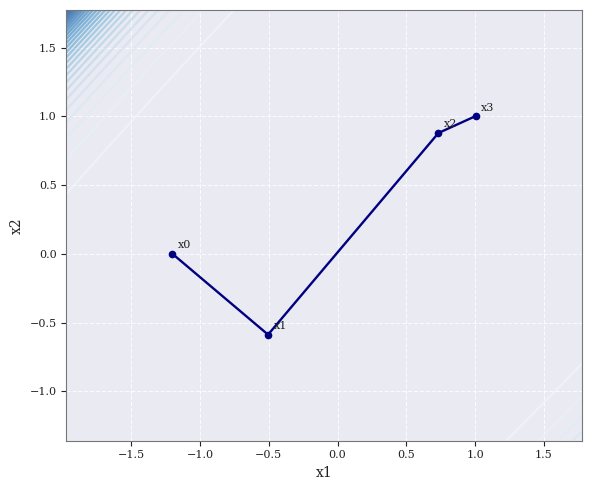

In [55]:
show_test_initial_data(
    "\u041a\u043e\u043d\u0442\u0440\u043e\u043b\u044c \u0447\u0435\u0440\u0435\u0437 \u0441\u0442\u0430\u0440\u0456 SymPy-\u0432\u0435\u0440\u0441\u0456\u0457",
    methods=["MNS NumPy", "MNS SymPy", "PARTAN-MNS NumPy", "PARTAN-MNS SymPy"],
    extra_rows=[{"parameter": "\u043a\u043e\u043d\u0442\u0440\u043e\u043b\u044c\u043d\u0438\u0439 max_iter", "value": "10"}],
)
old_check = old_sympy_check(max_iter_mns=10, max_iter_partan=10, eps=1e-6)
current_check = compare_methods(BASE_PARAMS)
current_check["джерело"] = "поточна NumPy-версія"
old_table = old_check["table"].copy()
old_table["джерело"] = "стара SymPy-версія"
show_table(pd.concat([current_check, old_table], ignore_index=True))

fig, ax = plt.subplots(figsize=(7, 5))
plot_trajectory(power_function, old_check["mns_points"], "Контрольна траєкторія МНС (SymPy)", cmap="Oranges", ax=ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
plot_trajectory(power_function, old_check["partan_points"], "Контрольна траєкторія ПАРТАН-МНС (SymPy)", cmap="Blues", ax=ax)
plt.tight_layout()
plt.show()

### 7.1. Контроль проблемної точки s4 для штрафної функції

Для точки `s4 = [-1; -1]` додатково перевіряємо МНС за допомогою аналітичного градієнта SymPy для зовнішньої штрафної функції з `Piecewise(max(0, g)^2)`. Якщо кількість ітерацій залишається великою, причина не в чисельному градієнті, а у зигзагоподібній поведінці самого МНС.

#### Початкові дані тесту

,параметр,значення
0,тест,Контроль проблемної точки s4 для штрафної функції
1,функція,f2(x) = (10*(x1 - x2)^2 + (x1 - 1)^2)^4
2,стартова точка,"[-1.20000000, 0.00000000]"
3,f(x_start),1.37e+05
4,методи,"MNS NumPy, MNS SymPy-gradient"
5,початкова точка s4,"[-1.0, -1.0]"
6,base_params[max_iter],1000
7,base_params[eps],0.001
8,base_params[derivative_h],0.001
9,base_params[gradient_scheme],central


,метод,початкова точка,коефіцієнт штрафу r,кінцева точка,значення штрафної функції,норма градієнта,кількість ітерацій,кількість викликів функції,статус
0,МНС NumPy,"[-1.00000000, -1.00000000]",1,"[0.71063197, 0.69660863]",5.394e-05,1.031e-03,1000,18185,ліміт ітерацій
1,МНС SymPy-gradient,"[-1.00000000, -1.00000000]",1,"[0.71422761, 0.70008051]",4.906e-05,1.153e-05,44,790,збіжність


#### МНС NumPy, s4

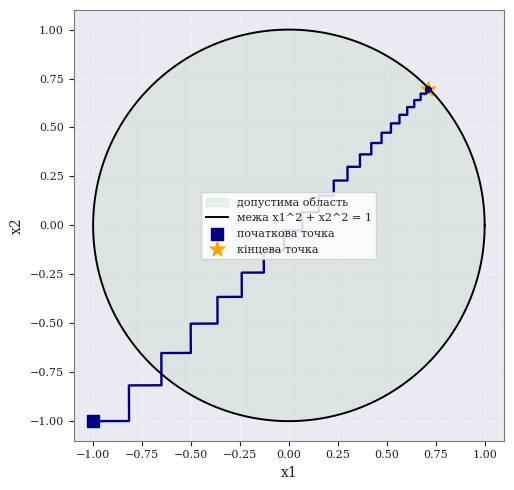

#### МНС SymPy-gradient, s4

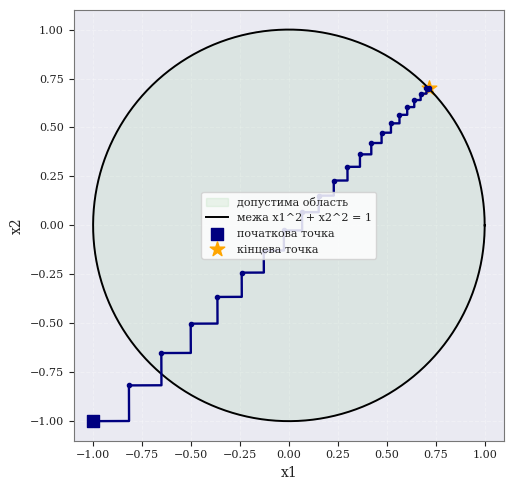

**Висновок.** Аналітичний градієнт SymPy дає практично таку саму довгу траєкторію для `s4`, як і NumPy-версія. Отже, велика кількість ітерацій пояснюється не помилкою чисельного диференціювання, а властивістю МНС для цієї початкової точки.

In [56]:
show_test_initial_data(
    "\u041a\u043e\u043d\u0442\u0440\u043e\u043b\u044c \u043f\u0440\u043e\u0431\u043b\u0435\u043c\u043d\u043e\u0457 \u0442\u043e\u0447\u043a\u0438 s4 \u0434\u043b\u044f \u0448\u0442\u0440\u0430\u0444\u043d\u043e\u0457 \u0444\u0443\u043d\u043a\u0446\u0456\u0457",
    methods=["MNS NumPy", "MNS SymPy-gradient"],
    params=BASE_PARAMS,
    extra_rows=[{"parameter": "\u043f\u043e\u0447\u0430\u0442\u043a\u043e\u0432\u0430 \u0442\u043e\u0447\u043a\u0430 s4", "value": "[-1.0, -1.0]"}],
)
s4_sympy_check = sympy_penalty_s4_check(BASE_PARAMS)
show_table(s4_sympy_check["table"])

for title, points in [
    ("МНС NumPy, s4", s4_sympy_check["numpy"]["points"]),
    ("МНС SymPy-gradient, s4", s4_sympy_check["sympy"]["points"]),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_circle_constraint(ax)
    mark_every = max(1, len(points) // 20)
    ax.plot(points[:, 0], points[:, 1], "-o", markersize=3, markevery=mark_every)
    ax.scatter(points[0, 0], points[0, 1], marker="s", s=70, label="початкова точка")
    ax.scatter(points[-1, 0], points[-1, 1], marker="*", s=120, label="кінцева точка")
    show_plot_heading(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

display(Markdown("**Висновок.** Аналітичний градієнт SymPy дає практично таку саму довгу траєкторію для `s4`, як і NumPy-версія. Отже, велика кількість ітерацій пояснюється не помилкою чисельного диференціювання, а властивістю МНС для цієї початкової точки."))

## 8. Загальні висновки

У роботі досліджено метод найшвидшого спуску (МНС) та ПАРТАН-МНС для мінімізації степеневої функції `f(x) = (10·(x₁ − x₂)² + (x₁ − 1)²)⁴` зі стартової точки `x₀ = (−1.2, 0)`.

**Безумовна оптимізація.**

- **ПАРТАН-МНС є ефективнішим за МНС** за кількістю ітерацій і кількістю викликів функції: ПАРТАН-МНС знаходить мінімум приблизно вдвічі швидше завдяки ПАРТАН-крокам, що скорочують зигзагоподібну траєкторію МНС.
- Найменша кількість обчислень функції досягається при кроці чисельного диференціювання `h ≈ 10⁻⁴`.
- Центральна схема обчислення похідних дає вищу точність при порівняній кількості обчислень.
- Метод ДСК-Пауелла виявився ефективнішим за золотий перетин за загальною кількістю викликів функції.
- Комбінований критерій зупинки є практичнішим: він враховує зміну точки та значення функції, а не лише норму градієнта.

**Умовна оптимізація (метод штрафних функцій).**

- Метод зовнішніх штрафних функцій дозволяє звести умовну задачу до послідовності безумовних.
- При збільшенні коефіцієнта штрафу `r` порушення обмеження `x₁² + x₂² ≤ 1` зменшується, а фінальна точка наближається до межі допустимої області.
- ПАРТАН-МНС у штрафній задачі також потребує значно менше ітерацій, ніж МНС.
- При `r = 100000` обидва методи знаходять точку, яка практично лежить на межі кола `x₁² + x₂² = 1`, і порушення обмеження стає меншим за `10⁻⁴`.